### Importing necessary libraries 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv


### Ignore Warnings

In [2]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings (e.g., from Lasso/ElasticNet)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Suppress runtime warnings (e.g., from NumPy or Pandas formatting)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Suppress future warnings (e.g., deprecated features)
warnings.filterwarnings("ignore", category=FutureWarning)

# Optional: suppress all remaining warnings globally
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv") 
# X = df.drop("purchaseValue", axis=1) 
# y = df['purchaseValue'] 
# from sklearn.dummy import DummyRegressor 
# model = DummyRegressor().fit(X,y) 
# X_test = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv") 
# y_pred=model.predict(X_test) 
# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred}) 
# submission.to_csv('submission.csv',index=False)

### Inspecting Columns

In [4]:
df.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

### Observerd 4 categories
* **Device Details**: People using better or newer devices often have a good experience on the site and usually have more money to spend.

* **Geographical Location** : Users from rich or developed areas are more likely to spend more because they have higher income.

* **User Behaviour** : The more often someone visits and interacts with the site, the more likely they are to buy something.

* **Traffic Source & Ads**: Where the user comes from (like Google, Facebook, or an ad) tells us how they found us, and some sources bring in more serious buyers.

### Device Related

In [5]:
device_columns = [
    "device.screenResolution",
    "screenSize",
    "device.mobileDeviceBranding",
    "device.mobileInputSelector",
    "device.mobileDeviceMarketingName",
    "device.operatingSystemVersion",
    "device.flashVersion",
    "browserMajor",
    "device.browserSize",
    "device.mobileDeviceModel",
    "device.language",
    "device.browserVersion",
    "device.screenColors"
]


In [6]:
for i in device_columns:
   print(f"{i}:{df[i].value_counts()}")

device.screenResolution:device.screenResolution
not available in demo dataset    116023
Name: count, dtype: int64
screenSize:screenSize
medium    116023
Name: count, dtype: int64
device.mobileDeviceBranding:device.mobileDeviceBranding
not available in demo dataset    116023
Name: count, dtype: int64
device.mobileInputSelector:device.mobileInputSelector
not available in demo dataset    116023
Name: count, dtype: int64
device.mobileDeviceMarketingName:device.mobileDeviceMarketingName
not available in demo dataset    116023
Name: count, dtype: int64
device.operatingSystemVersion:device.operatingSystemVersion
not available in demo dataset    116023
Name: count, dtype: int64
device.flashVersion:device.flashVersion
not available in demo dataset    116023
Name: count, dtype: int64
browserMajor:browserMajor
not available in demo dataset    116023
Name: count, dtype: int64
device.browserSize:device.browserSize
not available in demo dataset    116023
Name: count, dtype: int64
device.mobileDevice

| Feature                            | Description / Summary                        |
| ---------------------------------- | -------------------------------------------- |
| `browser`                          | Multiple values available                    |
| `os`                               | Multiple values available                    |
| `deviceType`                       | Multiple values available                    |
| `device.isMobile`                  | Binary (True/False)                          |
| `device.screenResolution`          | Single value (not available in demo dataset) |
| `screenSize`                       | Single value (use **median** value)          |
| `device.mobileDeviceBranding`      | Single value (not available in demo dataset) |
| `device.mobileInputSelector`       | Single value (not available in demo dataset) |
| `device.mobileDeviceMarketingName` | Single value (not available in demo dataset) |
| `device.operatingSystemVersion`    | Single value (not available in demo dataset) |
| `device.flashVersion`              | Single value (not available in demo dataset) |
| `browserMajor`                     | Single value (not available in demo dataset) |
| `device.browserSize`               | Single value (not available in demo dataset) |
| `device.mobileDeviceModel`         | Single value (not available in demo dataset) |
| `device.language`                  | Single value (not available in demo dataset) |
| `device.browserVersion`            | Single value (not available in demo dataset) |
| `device.screenColors`              | Single value (not available in demo dataset) |


### Columns inspections 
* **useless columns in device related** : device.screenResolution, screenSize (use median value) ,device.mobileDeviceBranding ,device.mobileInputSelector, device.mobileDeviceMarketingName ,device.operatingSystemVersion ,device.flashVersion ,browserMajor ,device.browserSize ,device.mobileDeviceModel, device.language, device.browserVersion, device.screenColors `all these columns contains single value that is not found in demo datasets.`
* dropped these columns.
* **usefull coumns in device related** :  browser, os ,deviceType ,device.isMobile `only values containing usefull data`
* retained these columns.

### EDA on Device Related items

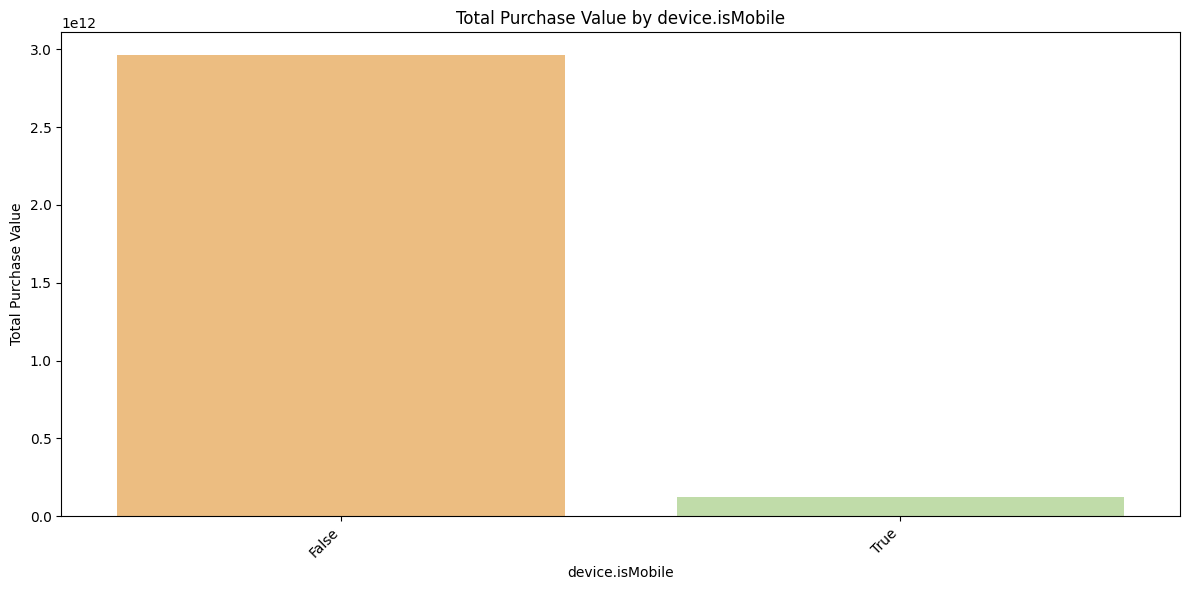

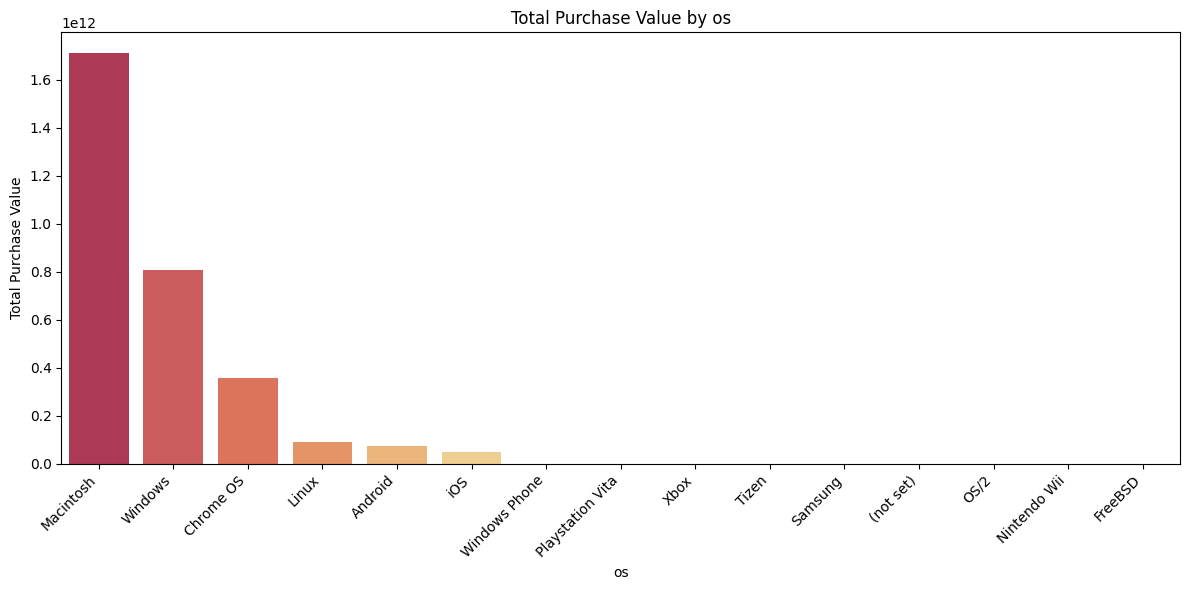

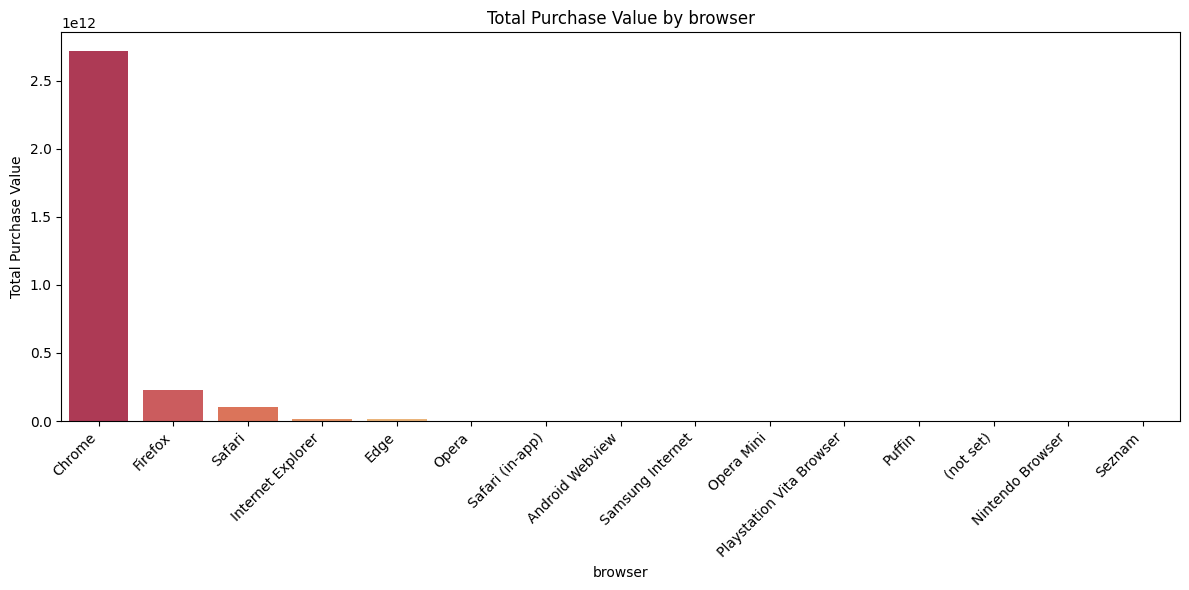

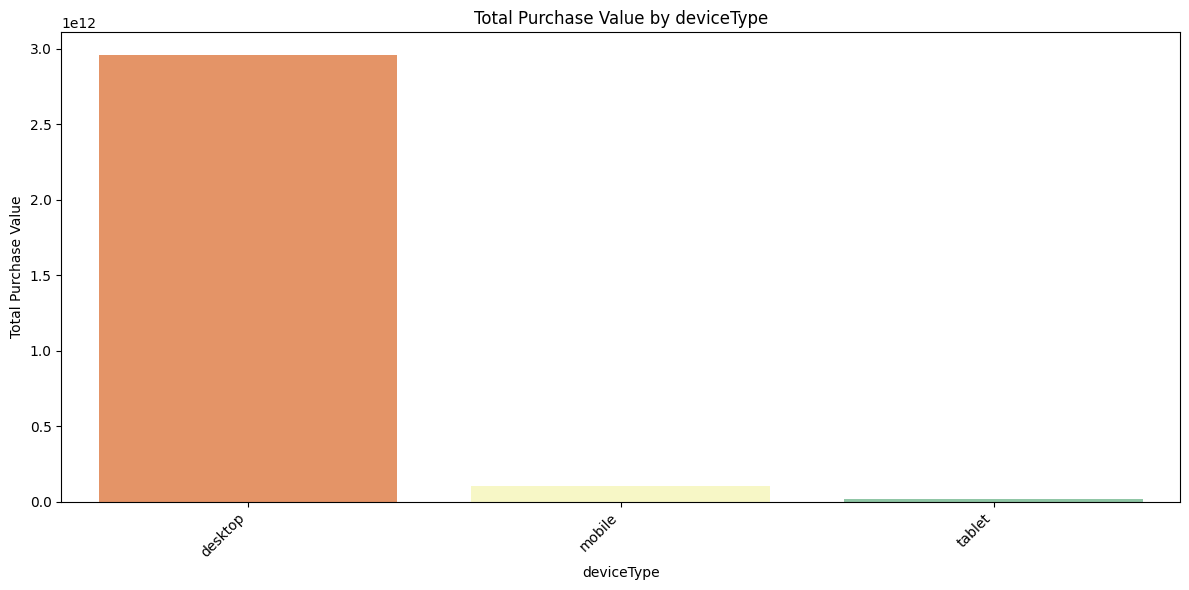

In [7]:
device=["device.isMobile","os","browser","deviceType"]

df[device] = df[device].fillna("others")

# Ensure purchaseValue is numeric
df["purchaseValue"] = pd.to_numeric(df["purchaseValue"], errors='coerce')

# Create bar plot for each feature
for col in device:
    plt.figure(figsize=(12, 6))
    grouped = df.groupby(col)["purchaseValue"].sum().sort_values(ascending=False).head(15)
    sns.barplot(x=grouped.index, y=grouped.values, palette="Spectral")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Total Purchase Value by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Purchase Value")
    plt.tight_layout()
    plt.show()

### Insight from EDA on device.
**device.isMobile**: 
* purchasing power if the device is mobile is lower.
* purchasing power of device is not mobile then it is higher.

**device** :
* desktop : higher screenSize higher purchasing power.
* mobile & tablet: lower purchasing power due to low size.

**os**:
* macintosh : higher purchase value , 
* windows, chromeos : moderate purchasing power
* others : lower purchasing power.

### Histogram on device related

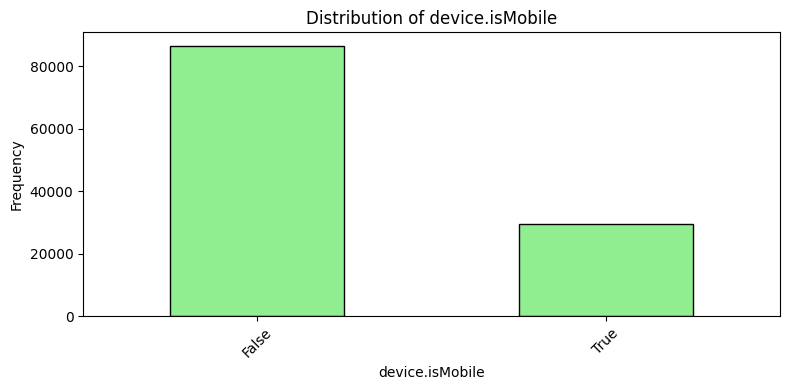

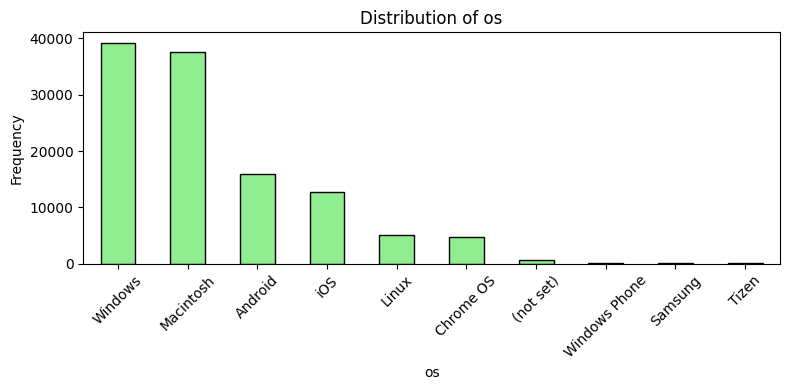

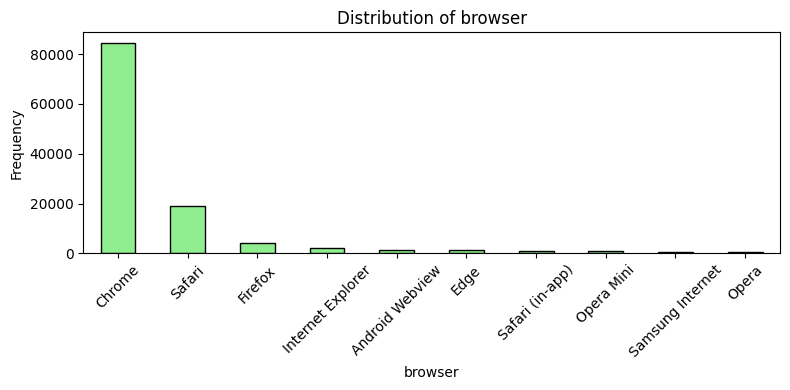

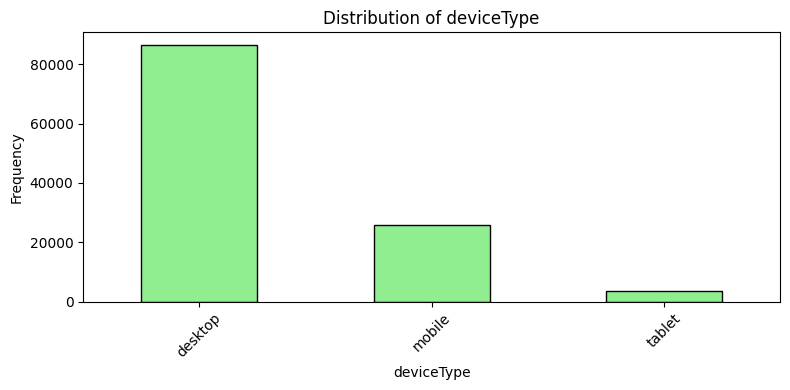

In [8]:
import matplotlib.pyplot as plt
for col in device:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        
        # If numeric data, use histogram
        if df[col].dtype in ['int64', 'float64']:
            plt.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
        else:
            # For categorical, use bar chart of value counts
            df[col].value_counts().head(10).plot(kind='bar', color='lightgreen', edgecolor='black')
        
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


### Correlation on device related

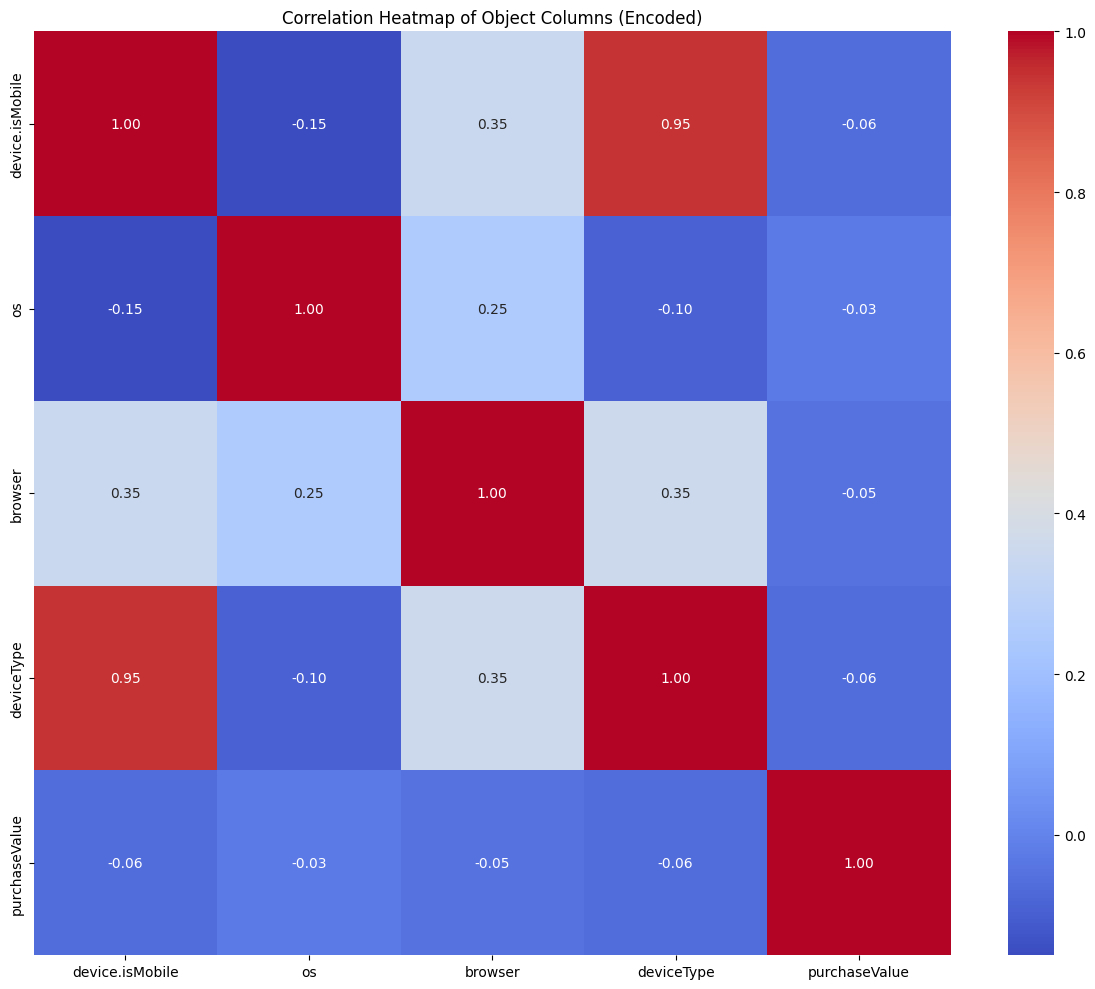

In [9]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df[device].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
df_encoded["purchaseValue"]=df["purchaseValue"]
# 3. Compute correlation matrix
corr = df_encoded.corr()

# 4. Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Object Columns (Encoded)")
plt.tight_layout()
plt.show()


In [10]:
df.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

### Traffic Source and Marketing Related

In [11]:
trafficSource=["trafficSource.isTrueDirect","trafficSource.adContent","trafficSource.keyword","trafficSource.adwordsClickInfo.slot","trafficSource.campaign","trafficSource","trafficSource.medium","trafficSource.adwordsClickInfo.isVideoAd","trafficSource.adwordsClickInfo.adNetworkType","socialEngagementType","trafficSource.adwordsClickInfo.page","trafficSource.referralPath","gclIdPresent"]
df[trafficSource].head()

,trafficSource.isTrueDirect,trafficSource.adContent,trafficSource.keyword,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,trafficSource,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,trafficSource.adwordsClickInfo.page,trafficSource.referralPath,gclIdPresent
0,NaN,NaN,NaN,NaN,(not set),youtube.com,referral,NaN,NaN,Not Socially Engaged,NaN,/intl/hr/yt/about/,0
1,True,NaN,NaN,NaN,(not set),(direct),(none),NaN,NaN,Not Socially Engaged,NaN,NaN,0
2,True,NaN,(not provided),NaN,(not set),google,organic,NaN,NaN,Not Socially Engaged,NaN,NaN,0
3,NaN,NaN,NaN,NaN,(not set),youtube.com,referral,NaN,NaN,Not Socially Engaged,NaN,/yt/about/ja/,0
4,True,NaN,NaN,NaN,(not set),(direct),(none),NaN,NaN,Not Socially Engaged,NaN,NaN,0


| Feature                                        | Description / Summary                 |
| ---------------------------------------------- | ------------------------------------- |
| `trafficSource.isTrueDirect`                   | Available                             |
| `trafficSource.adContent`                      | 97% null, \~1% = "Top"                |
| `trafficSource.keyword`                        | 96% null                              |
| `trafficSource.adwordsClickInfo.slot`          | 97% null, \~1% = "Google Merchandise" |
| `trafficSource.campaign`                       | 95% null, \~2% = "Data promo"         |
| `trafficSource.medium`                         | Available                             |
| `trafficSource.adwordsClickInfo.isVideoAd`     | 96% null, \~4% = "False"              |
| `trafficSource.adwordsClickInfo.adNetworkType` | 96% null, \~4% = "Google"             |
| `socialEngagementType`                         | Single value = "Not Socially Engaged" |
| `trafficSource.adwordsClickInfo.page`          | Single value = 1                      |
| `trafficSource.referralPath`                   | 63% null, \~15% = "/"                 |


### Traffic Source and ad Related
1. **Features with >95% Null Values — Dropped**
* Columns like adContent, keyword, slot, campaign, etc. have over 95% missing values, making them unreliable for analysis.
* These features showed minimal non-null entries (e.g., only ~1–2% values like "Top" or "Data promo") — not meaningful enough to retain.
2. **Features with a Single Constant Value — Dropped**
* Columns like socialEngagementType ("Not Socially Engaged") and adwordsClickInfo.page (1) have no variability, providing no modeling value.
* Since they do not differentiate records in any way, they are excluded from further processing.
3. **Features with Informative Content — Retained**
* Features like isTrueDirect and medium are fully populated and critical for understanding traffic source behavior.
* Although referralPath has ~63% nulls, the remaining values (especially entries like "/") provide insight into user flow and are retained.


In [12]:
trafficSource=["trafficSource.isTrueDirect","trafficSource.adContent","trafficSource.keyword","trafficSource.adwordsClickInfo.slot","trafficSource.campaign","trafficSource","trafficSource.medium","trafficSource.adwordsClickInfo.isVideoAd","trafficSource.adwordsClickInfo.adNetworkType","socialEngagementType","trafficSource.adwordsClickInfo.page","trafficSource.referralPath","gclIdPresent"]
df[trafficSource].replace(np.nan,"others",inplace=True)

### Impact of traffic source on purchase value

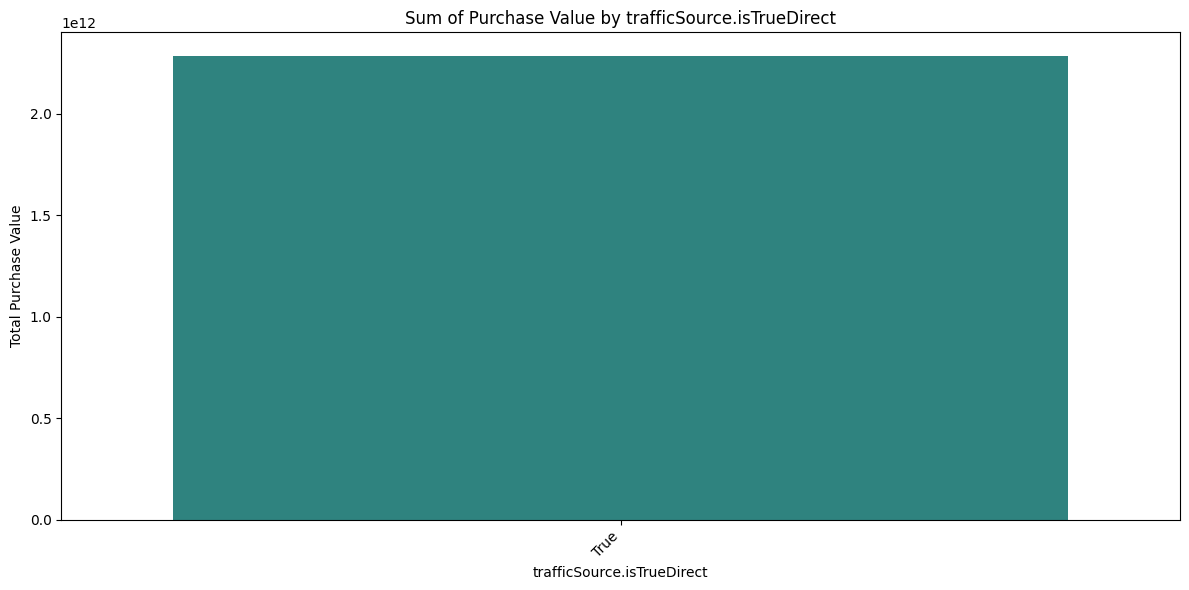

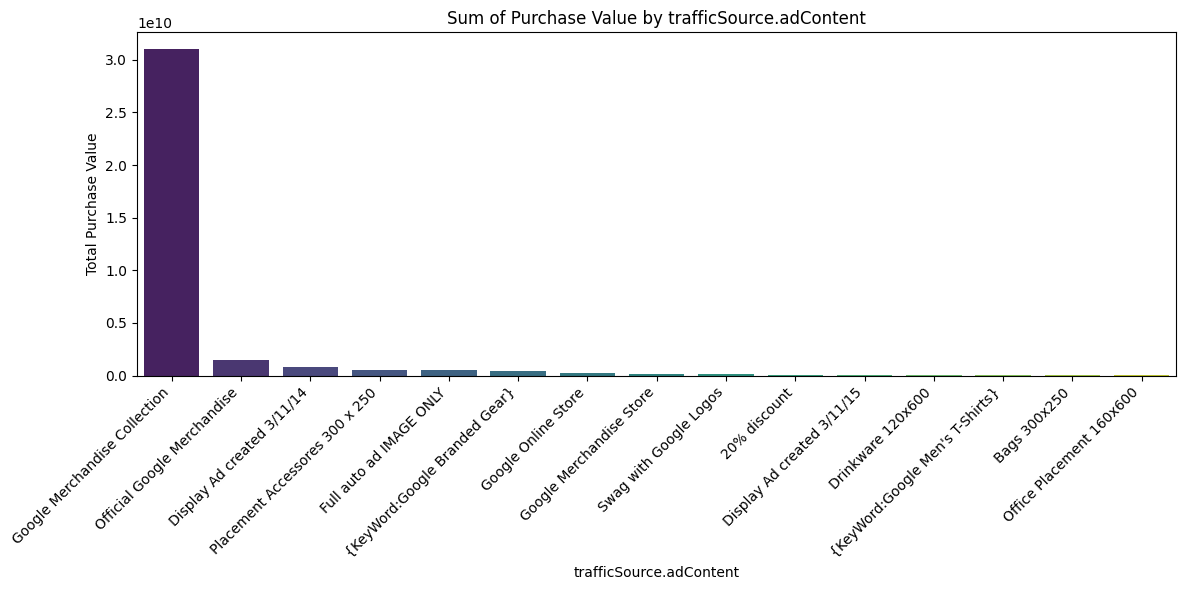

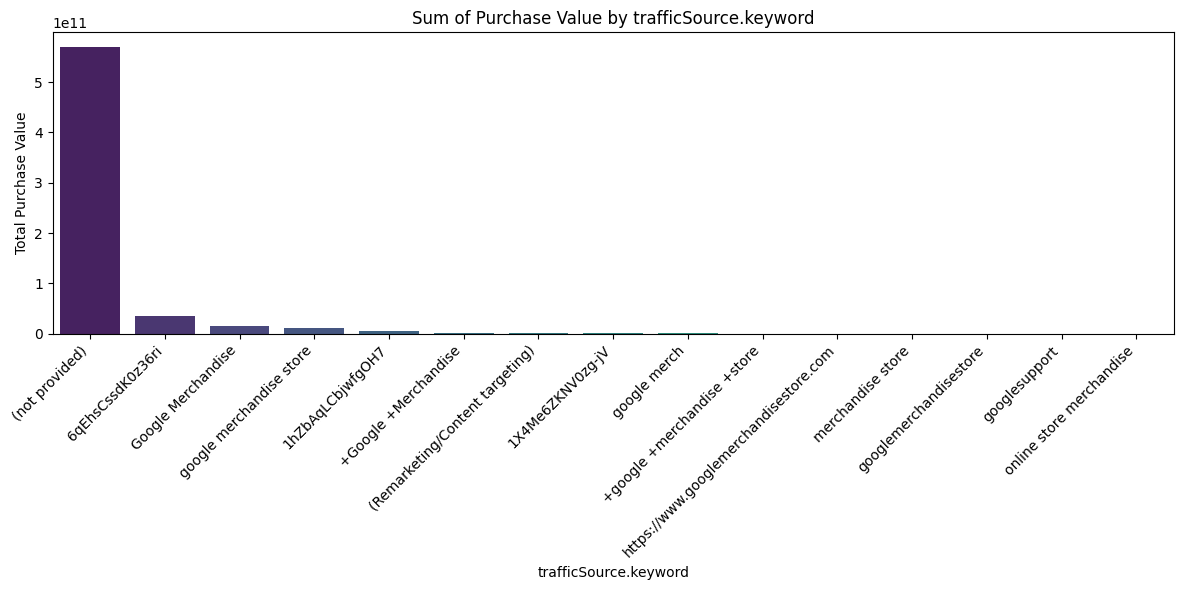

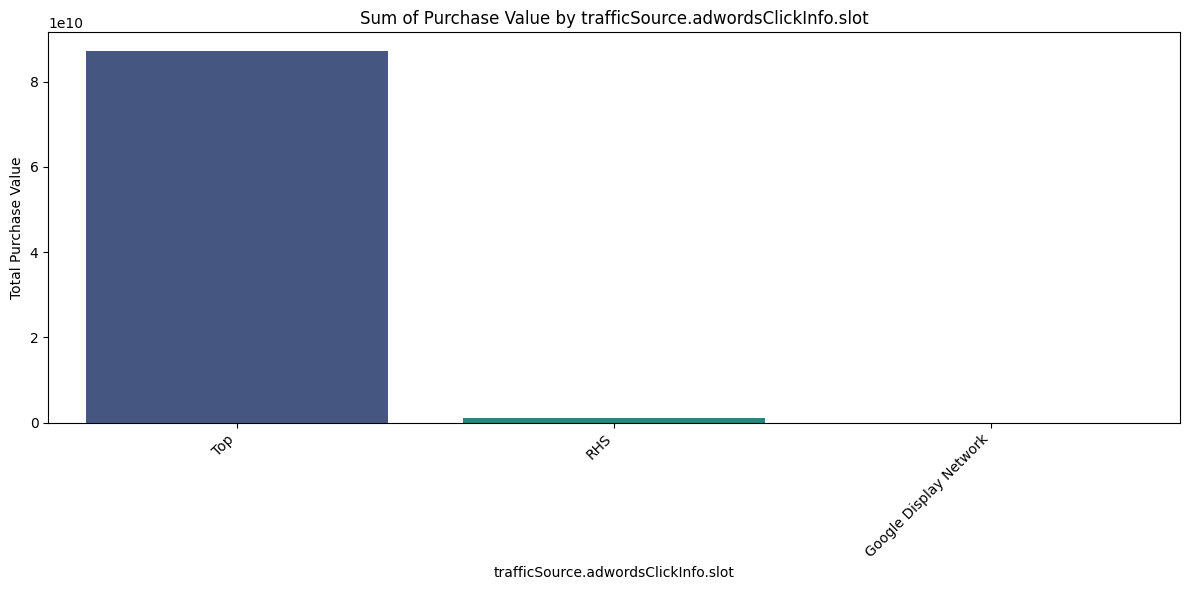

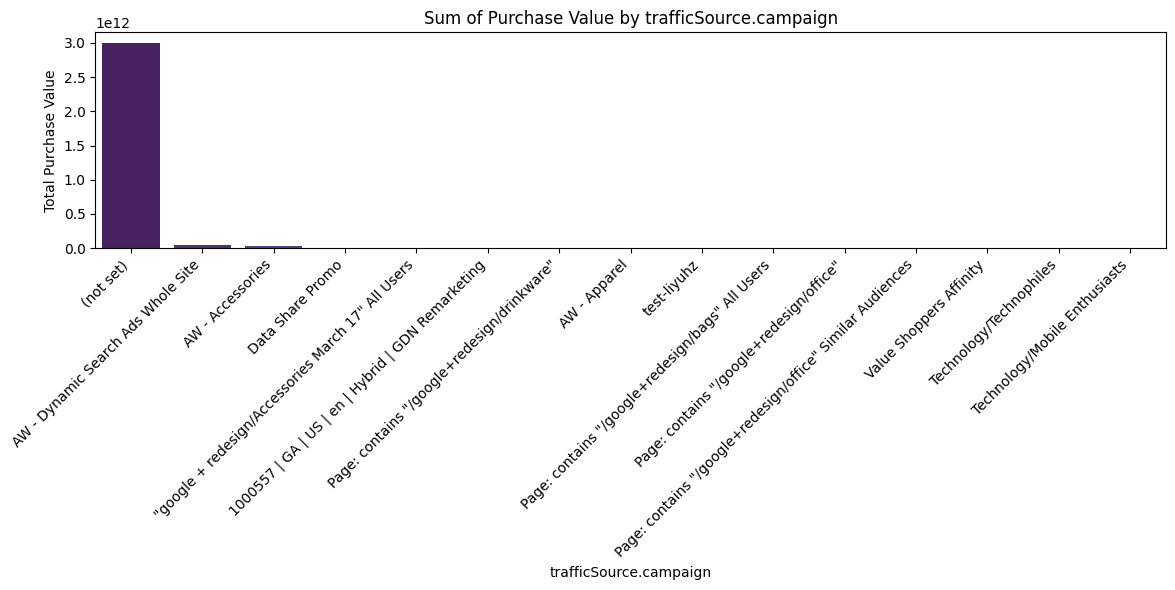

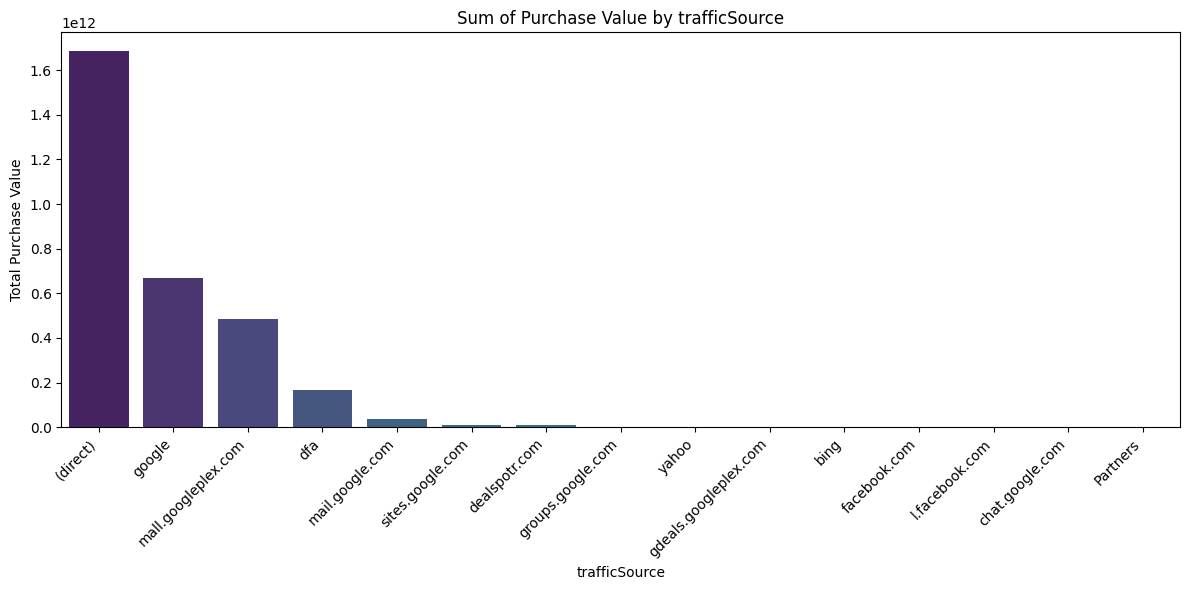

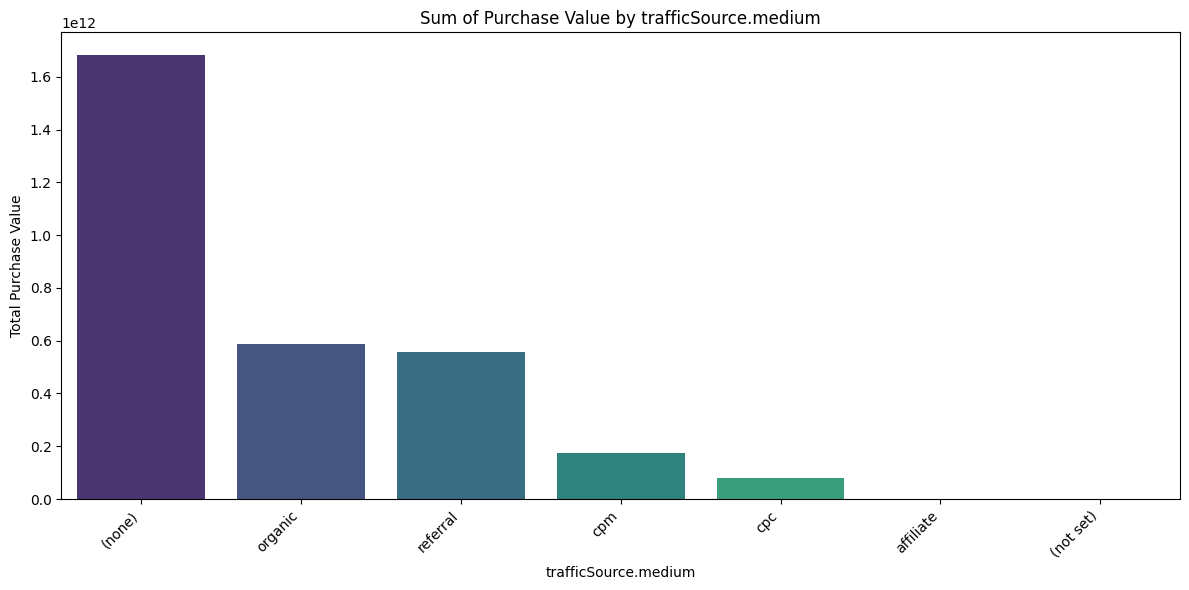

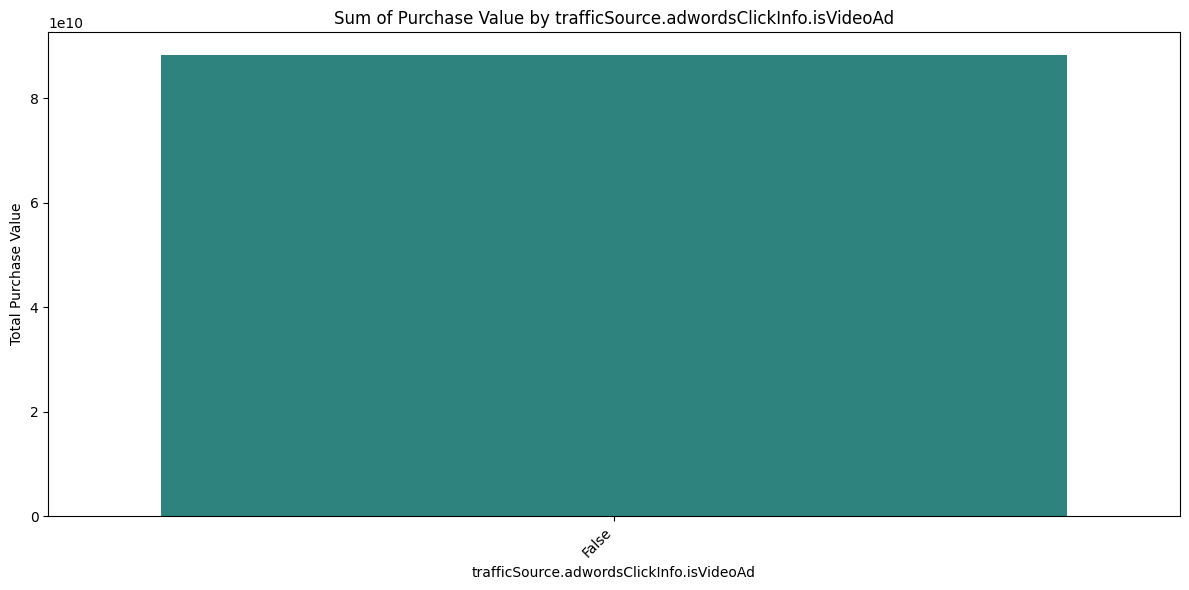

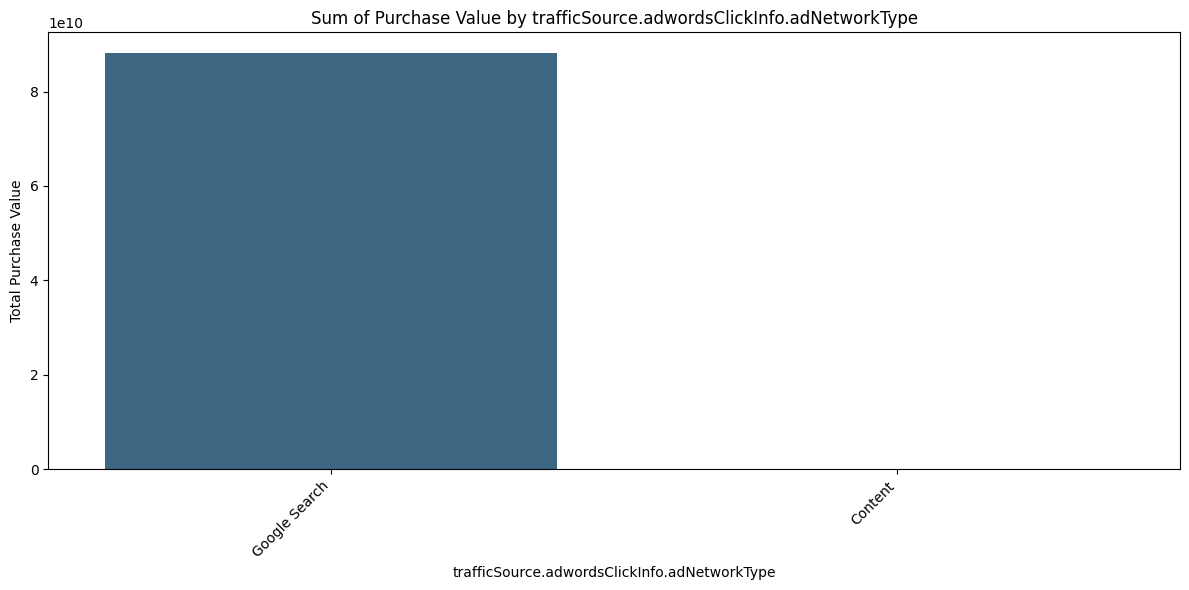

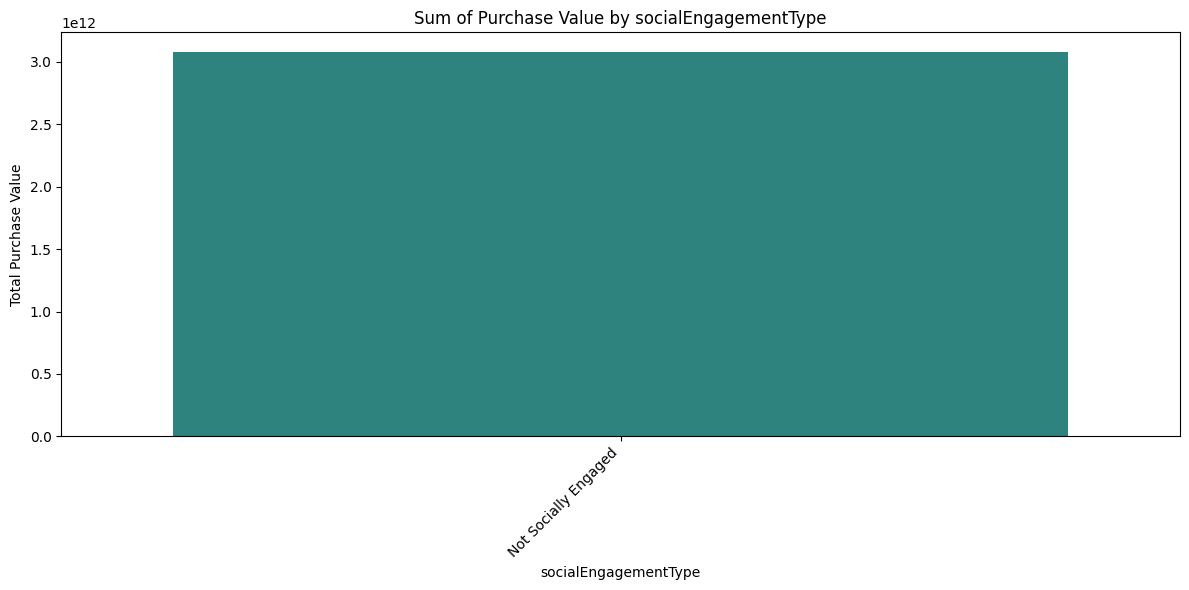

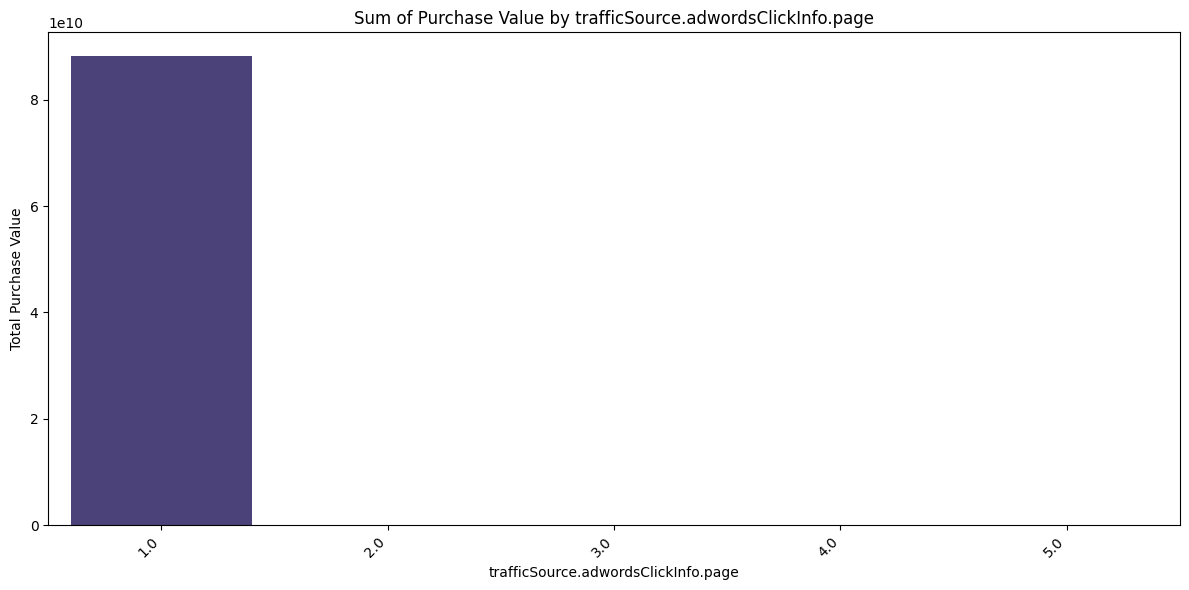

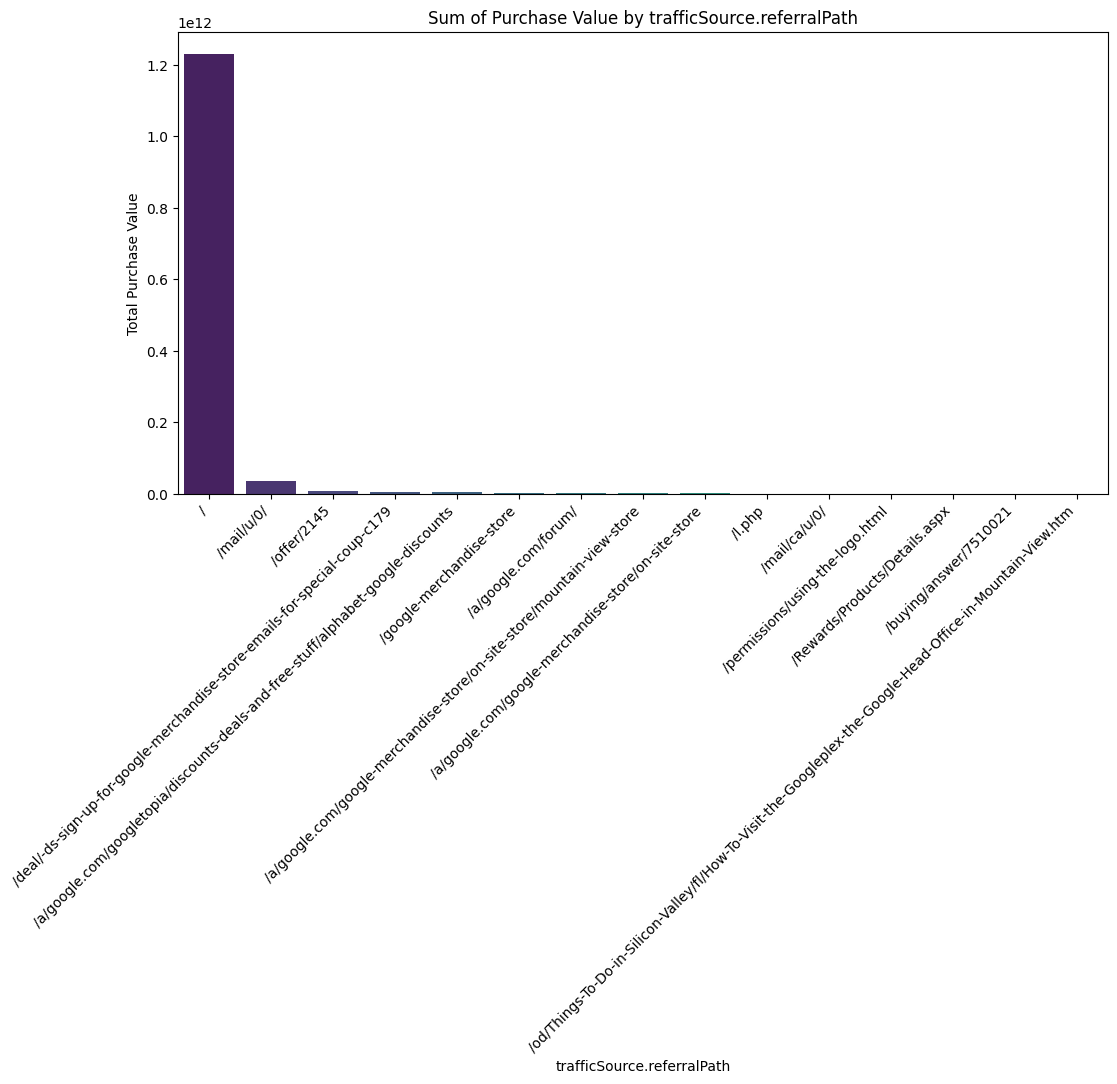

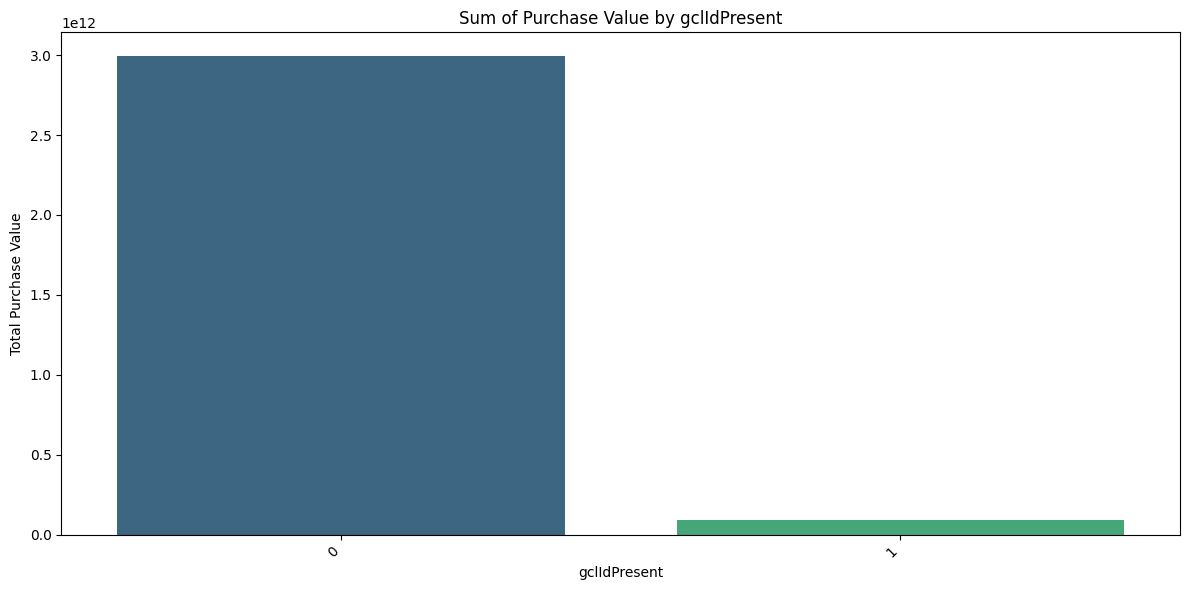

In [13]:
df["purchaseValue"] = pd.to_numeric(df["purchaseValue"], errors='coerce')

# Step 2 & 3: Plot for each traffic feature
for col in trafficSource:
    plt.figure(figsize=(12, 6))
    grouped = df.groupby(col)["purchaseValue"].sum().sort_values(ascending=False).head(15)  # top 15 categories
    sns.barplot(x=grouped.index, y=grouped.values, palette="viridis")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Sum of Purchase Value by {col}")
    plt.ylabel("Total Purchase Value")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Insight on Traffic Source and ad Related
**Traffic Source**
* direct : has more purchase value.
  
**gclIdPresent**
* if google click is not present then higher purchase.
  
**referral path**
* (/) direct , (mail/u/0) has highest purchasing value.
  
**trafficSource.adwordsClickInfo.slot**
* top has more purchase value.



### Correlations between traffic sources

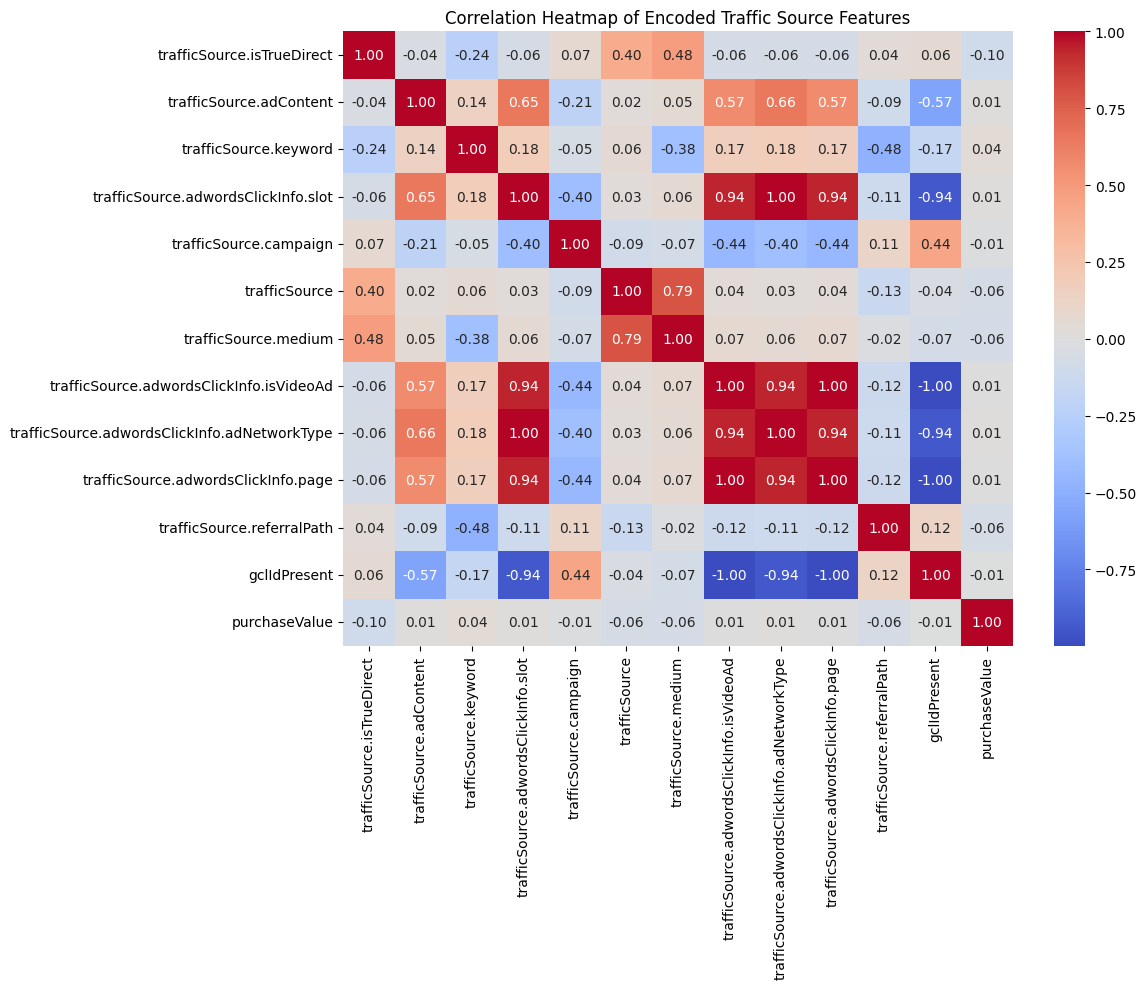

In [14]:
trafficSource=["trafficSource.isTrueDirect","trafficSource.adContent","trafficSource.keyword","trafficSource.adwordsClickInfo.slot","trafficSource.campaign","trafficSource","trafficSource.medium","trafficSource.adwordsClickInfo.isVideoAd","trafficSource.adwordsClickInfo.adNetworkType","trafficSource.adwordsClickInfo.page","trafficSource.referralPath","gclIdPresent"]
df[trafficSource].replace(np.nan,"others",inplace=True)
df[trafficSource] = df[trafficSource].fillna("others")
df_encoded = df[trafficSource].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))
df_encoded["purchaseValue"]=df["purchaseValue"]
corr = df_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Encoded Traffic Source Features")
plt.tight_layout()
plt.show()

### Insight on correlations with traffic Source
* 

In [15]:
df[["gclIdPresent","trafficSource.adwordsClickInfo.isVideoAd"]]

,gclIdPresent,trafficSource.adwordsClickInfo.isVideoAd
0,0,others
1,0,others
2,0,others
3,0,others
4,0,others
...,...,...
116018,0,others
116019,0,others
116020,0,others
116021,0,others


###  Region Based Analysis

| Feature                      | Description / Summary                        |
| ---------------------------- | -------------------------------------------- |
| `geoCluster`                 | Available                                    |
| `geoNetwork.networkDomain`   | Multiple values                              |
| `geoNetwork.region`          | 52% null, \~16% = "California"               |
| `geoNetwork.networkLocation` | Single value (not available in demo dataset) |
| `geoNetwork.subContinent`    | \~55% = "North America"                      |
| `locationCountry`            | \~52% = "United States", \~5% = "India"      |
| `geoNetwork.city`            | 52% = "not available in demo dataset"        |
| `geoNetwork.metro`           | 52% null, \~16% = "not set"                  |
| `locationZone`               | Single value = "8"                           |
| `geoNetwork.continent`       | \~60% = "Americas", \~19% = "Asia"           |


### Insight on Location based 
**location zone** : single value.
* dropped
**other** : multiple value.
* retained.

In [16]:
df.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

### Impact on geoNetwork on purchase value

In [17]:
region_features = ["geoCluster","geoNetwork.networkDomain","geoNetwork.region","geoNetwork.networkLocation","geoNetwork.subContinent","locationCountry","geoNetwork.city", "geoNetwork.metro","locationZone","geoNetwork.continent"]
df[region_features]

,geoCluster,geoNetwork.networkDomain,geoNetwork.region,geoNetwork.networkLocation,geoNetwork.subContinent,locationCountry,geoNetwork.city,geoNetwork.metro,locationZone,geoNetwork.continent
0,Region_2,domain1,Washington,not available in demo dataset,Northern America,United States,Redmond,Seattle-Tacoma WA,8,Americas
1,Region_3,domain3,California,not available in demo dataset,Northern America,United States,Mountain View,San Francisco-Oakland-San Jose CA,8,Americas
2,Region_2,domain1,Lombardy,not available in demo dataset,Southern Europe,Italy,Milan,(not set),8,Europe
3,Region_4,domain3,not available in demo dataset,not available in demo dataset,Eastern Asia,Japan,not available in demo dataset,not available in demo dataset,8,Asia
4,Region_3,domain1,not available in demo dataset,not available in demo dataset,Northern America,United States,not available in demo dataset,not available in demo dataset,8,Americas
...,...,...,...,...,...,...,...,...,...,...
116018,Region_3,domain1,New York,not available in demo dataset,Northern America,United States,New York,New York NY,8,Americas
116019,Region_5,domain2,California,not available in demo dataset,Northern America,United States,Mountain View,San Francisco-Oakland-San Jose CA,8,Americas
116020,Region_1,domain2,Delhi,not available in demo dataset,Southern Asia,India,New Delhi,(not set),8,Asia
116021,Region_5,domain1,Tennessee,not available in demo dataset,Northern America,United States,Nashville,Nashville TN,8,Americas


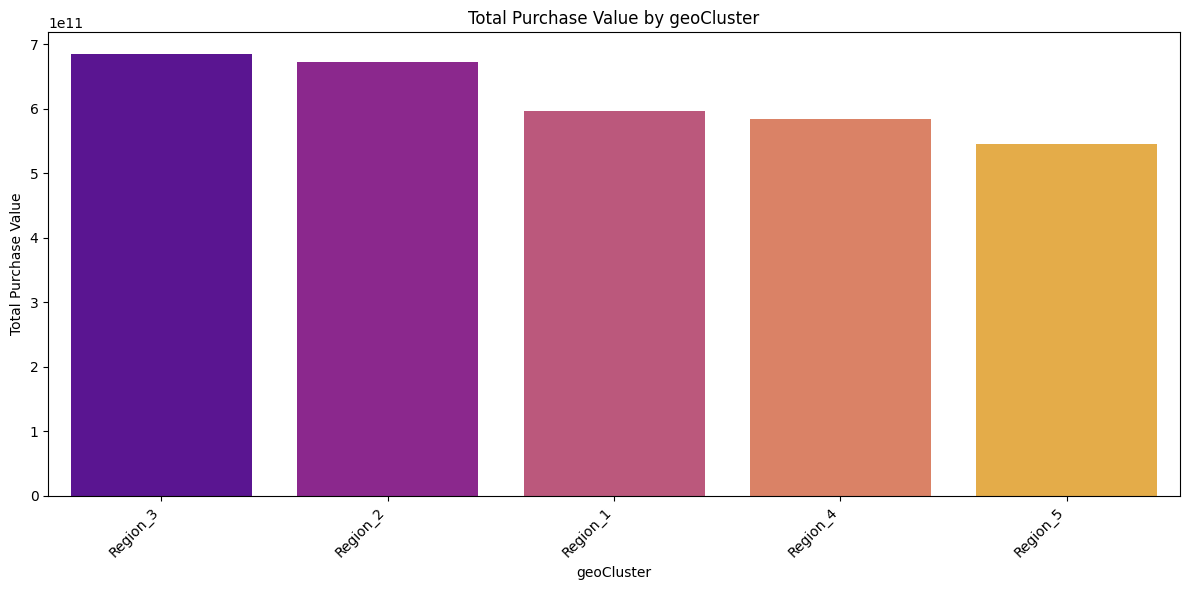

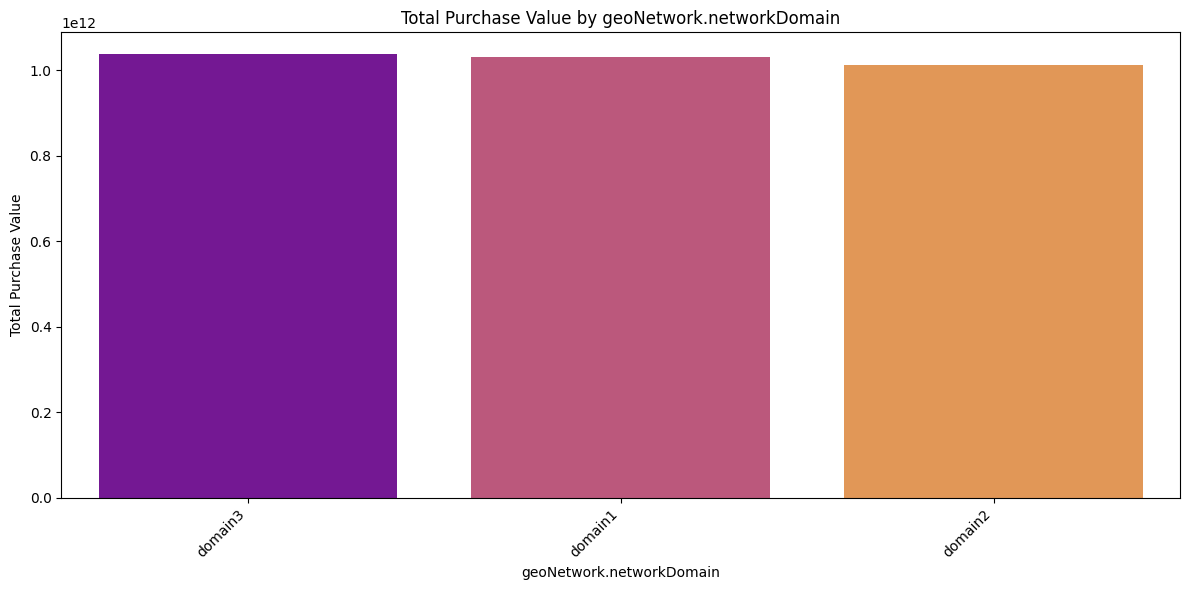

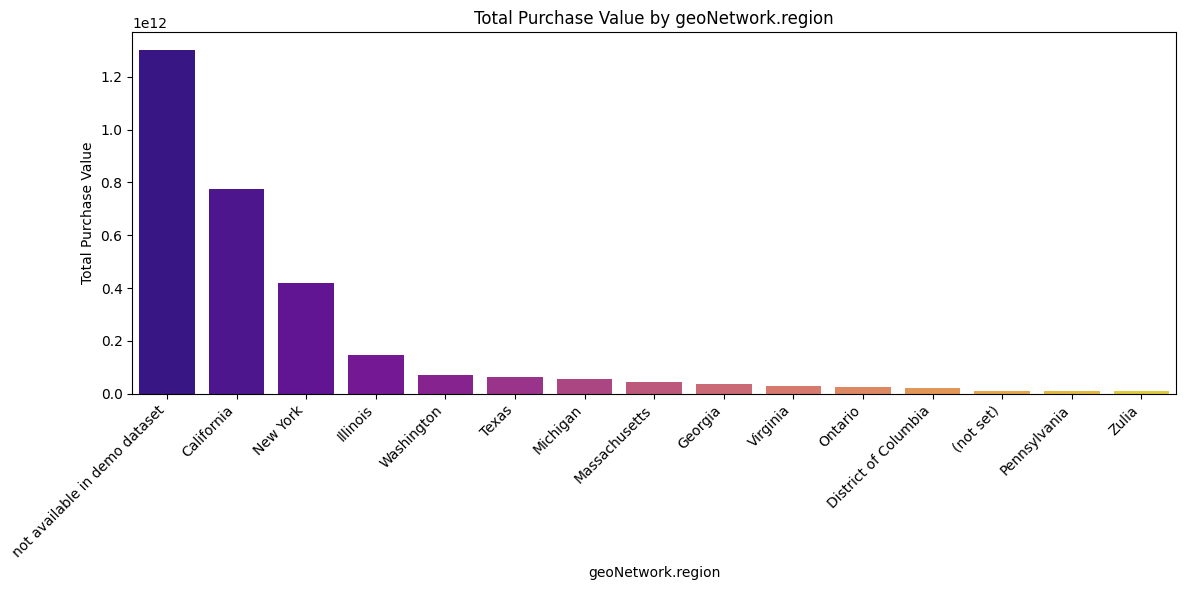

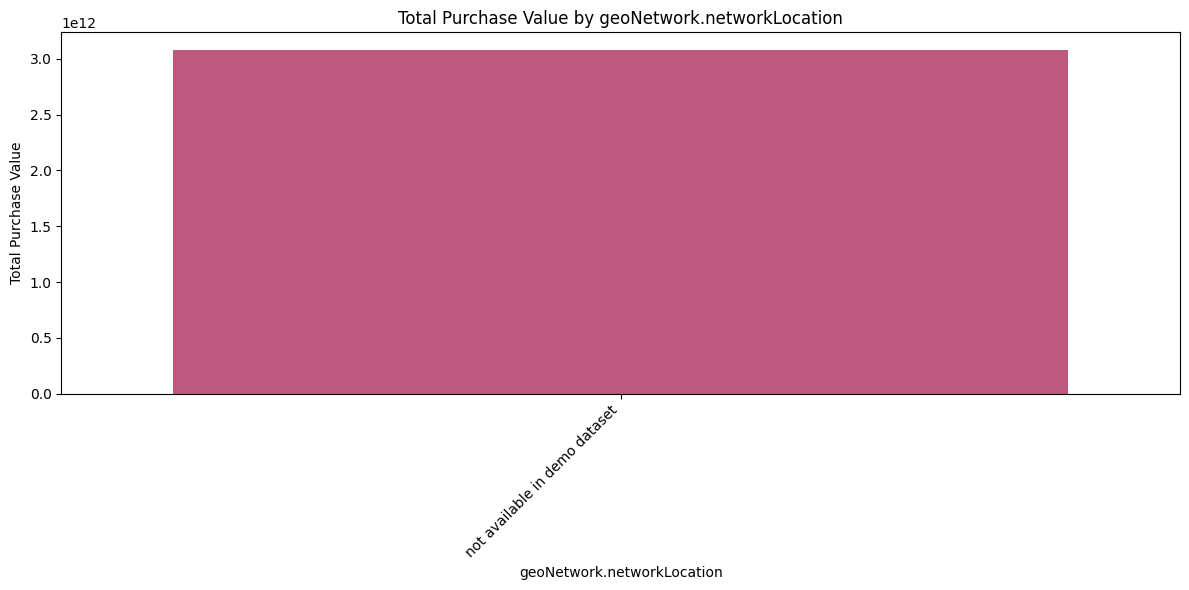

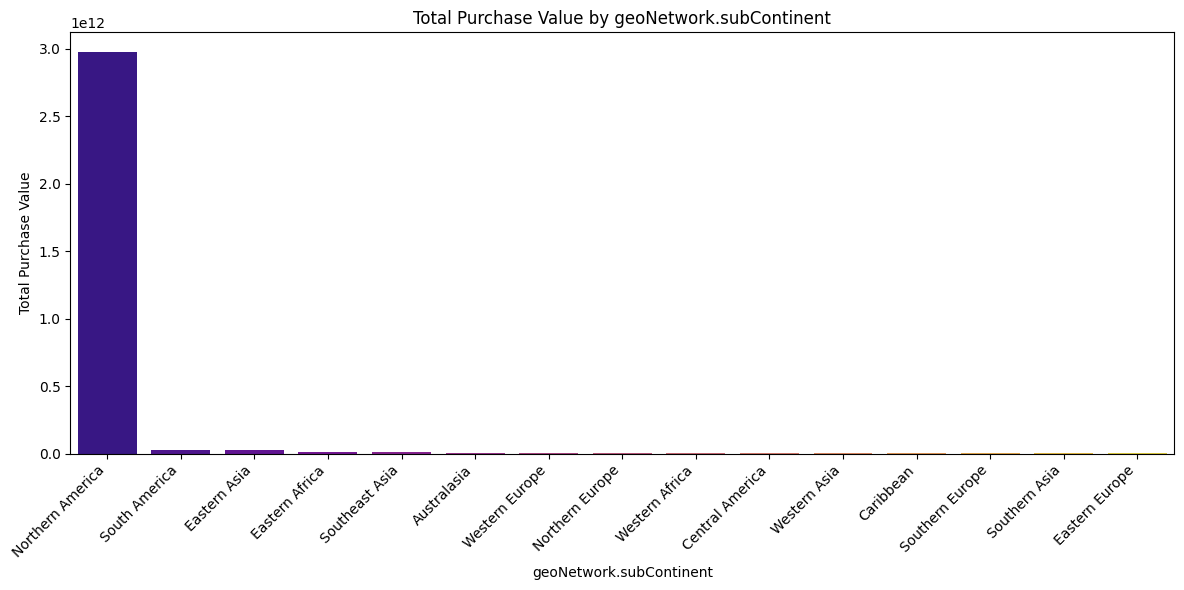

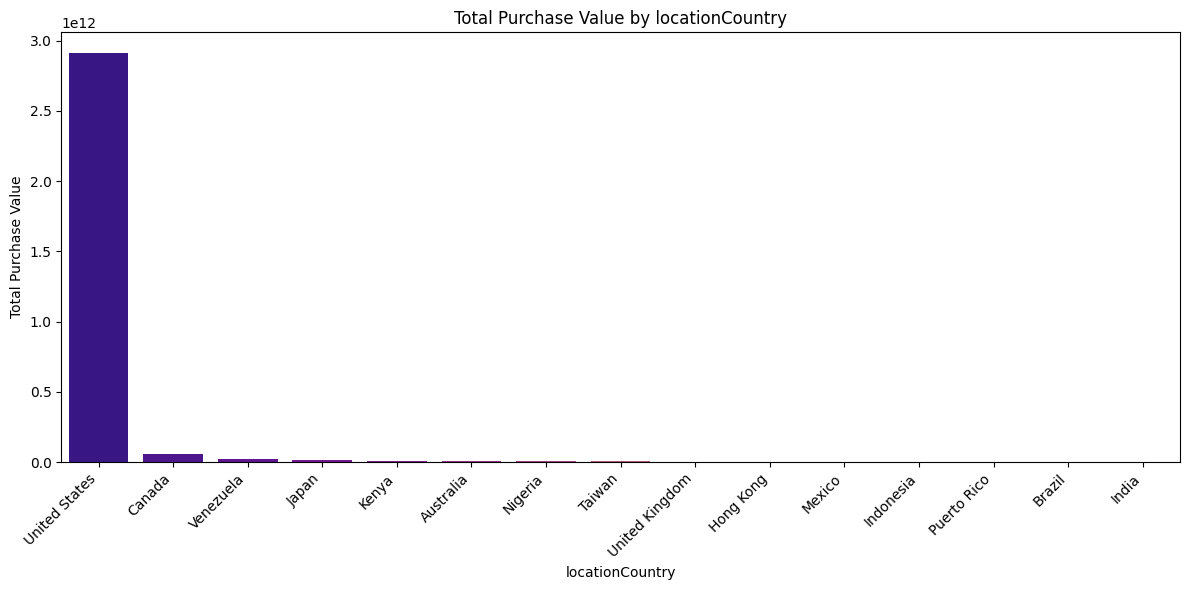

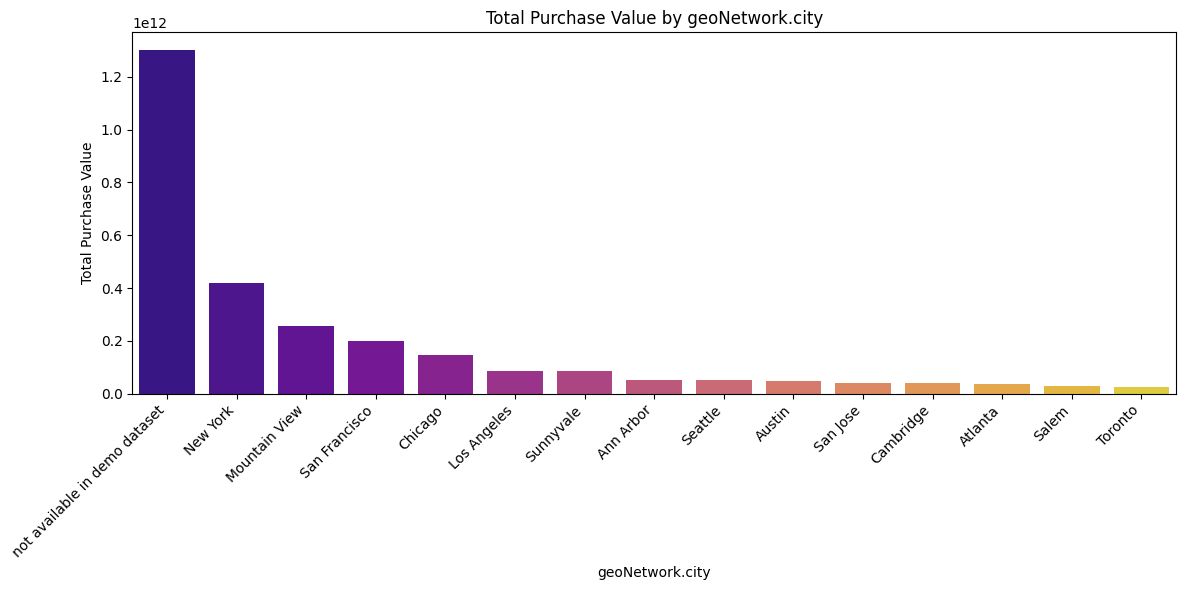

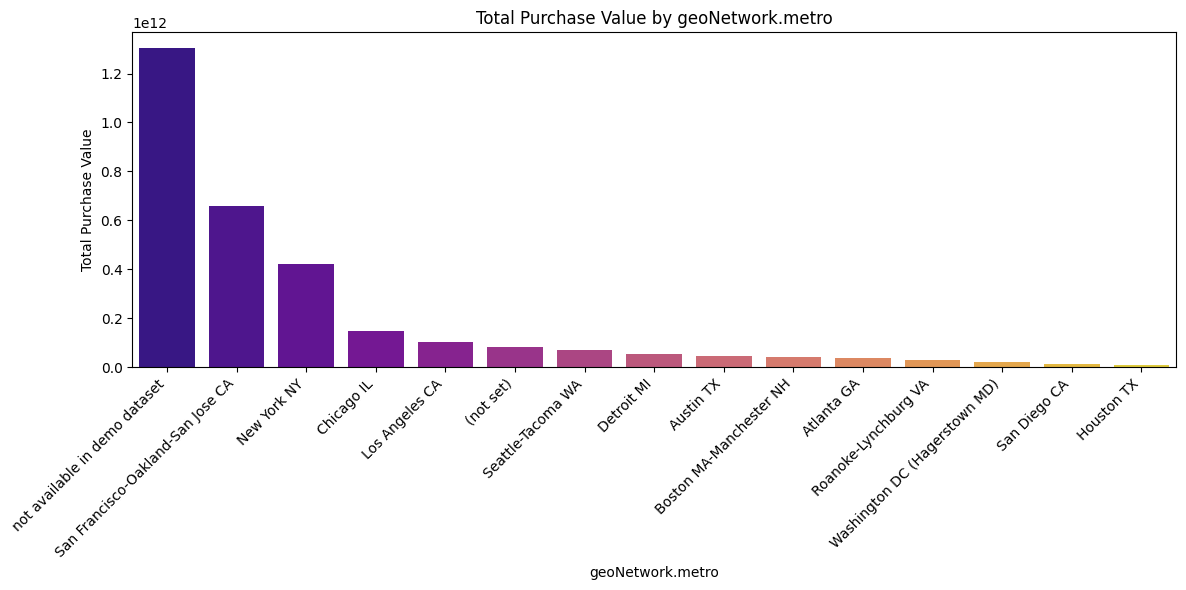

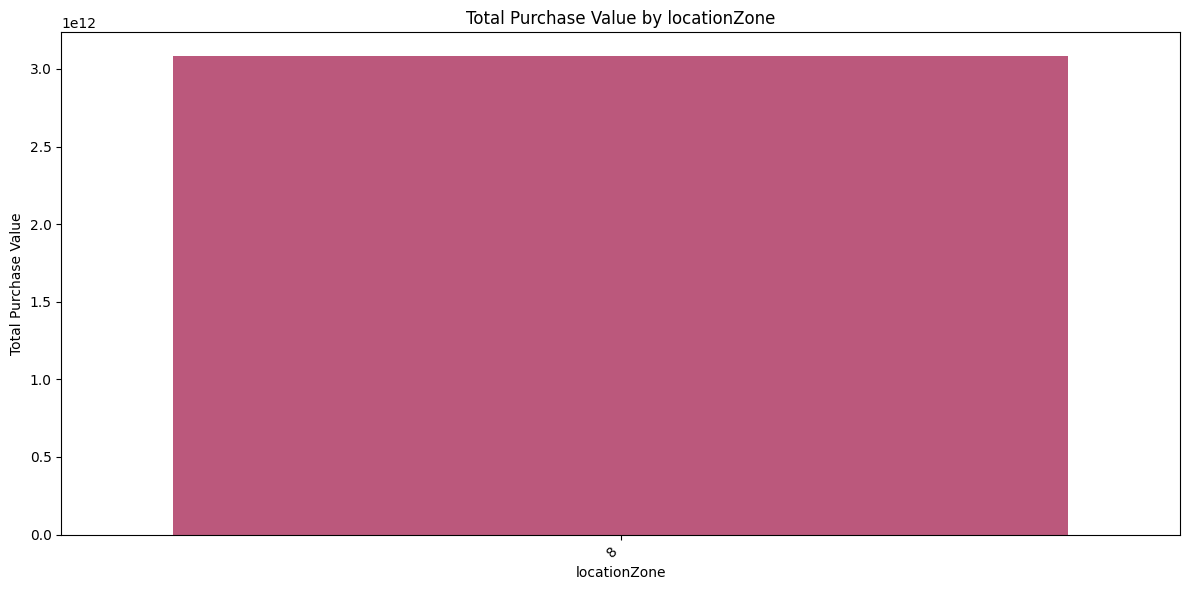

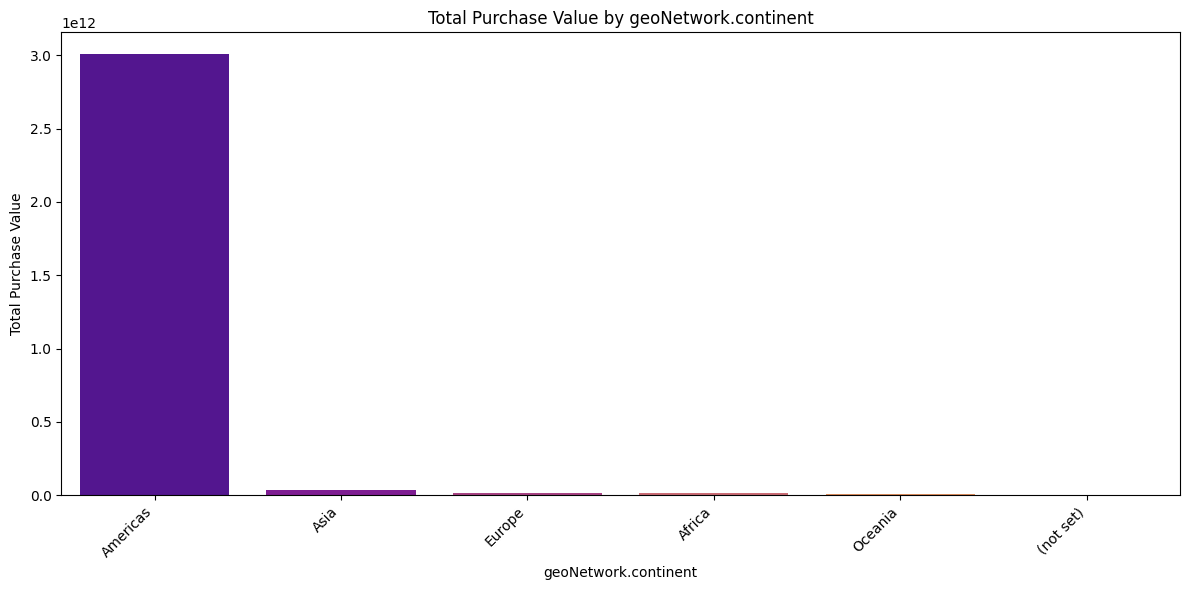

In [18]:
df[region_features] = df[region_features].fillna("others")

# Ensure purchaseValue is numeric
df["purchaseValue"] = pd.to_numeric(df["purchaseValue"], errors='coerce')

# Create bar plot for each feature
for col in region_features:
    plt.figure(figsize=(12, 6))
    grouped = df.groupby(col)["purchaseValue"].sum().sort_values(ascending=False).head(15)
    sns.barplot(x=grouped.index, y=grouped.values, palette="plasma")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Total Purchase Value by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Purchase Value")
    plt.tight_layout()
    plt.show()

### Insights on Locations
Continent & Subcontinent: 
* **America** : In this dataset the America has more purchase value.
* others continent doesnot impact
* **North America** : Has high purchase value.
  
**Domain & Cluster**
* Domain didn't affect the purchase from the train dataset.
* dropped
* Cluster few cluster have high and few has low purchasing power.

**Country and city**
* **USA**(Country): Contributes to more purchasing
* **New york**(City) : Contributes to more purchasing.
* Distribution of City and metro is same.
  
**

### Correlation between geoNetwork

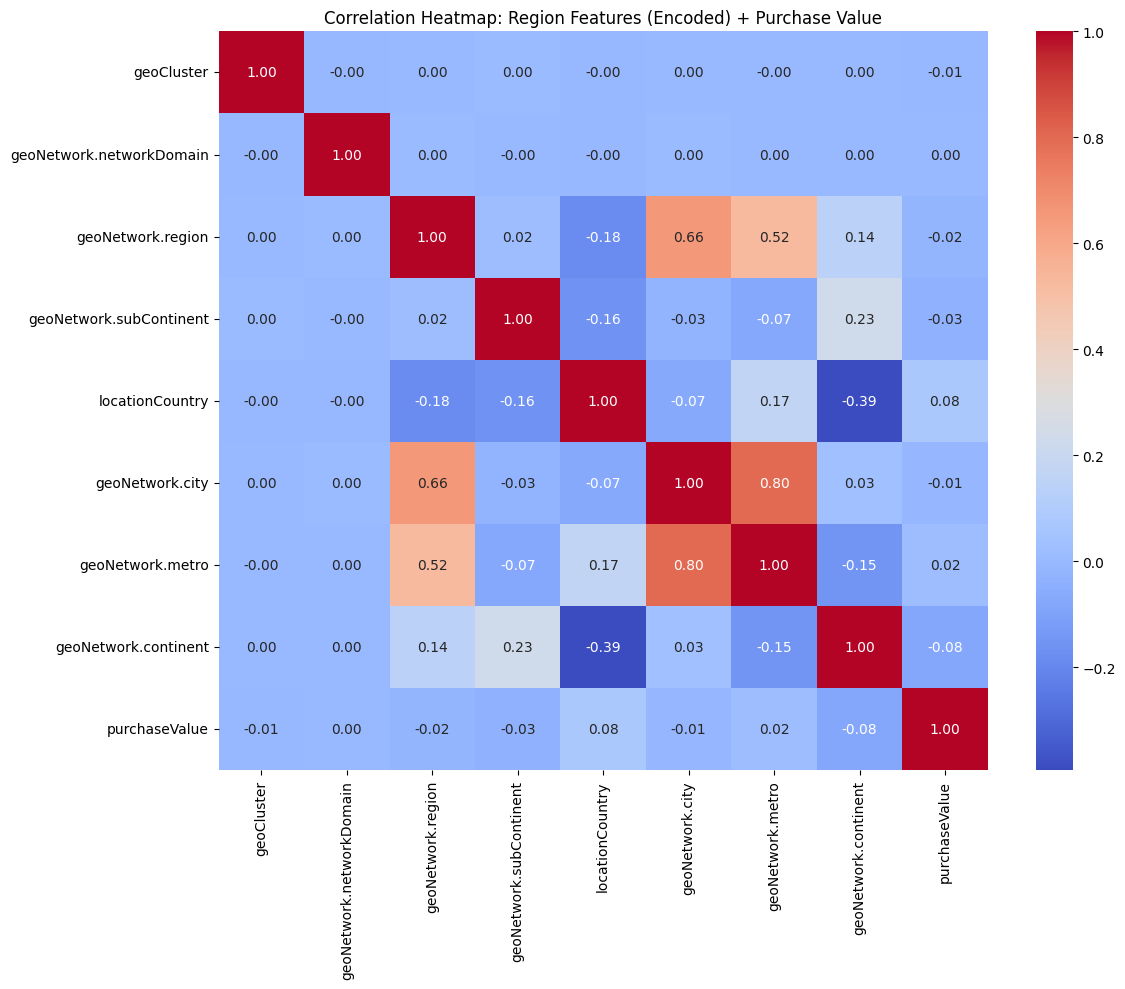

In [19]:
region_features = ["geoCluster","geoNetwork.networkDomain","geoNetwork.region","geoNetwork.subContinent","locationCountry","geoNetwork.city", "geoNetwork.metro","geoNetwork.continent"]

df_encoded = df[region_features].apply(lambda col: LabelEncoder().fit_transform(col.astype(str)))

# Add numeric purchaseValue
df_encoded["purchaseValue"] = pd.to_numeric(df["purchaseValue"], errors='coerce')

# Compute correlation matrix
corr = df_encoded.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Region Features (Encoded) + Purchase Value")
plt.tight_layout()
plt.show()

### Insight on correlations 
* city and metro has high correlation of 0.80
* hiearchical relationship
* Continent -> Subcontinent -> locationCountry -> Region -> City.
* But most of the value of city and region are not usefully data.

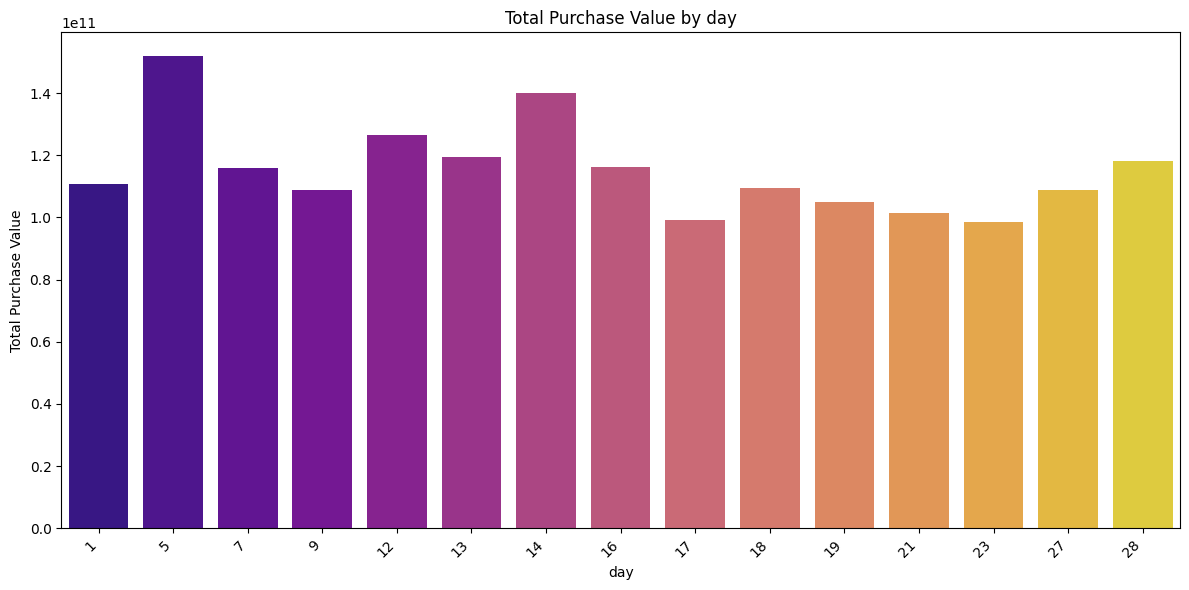

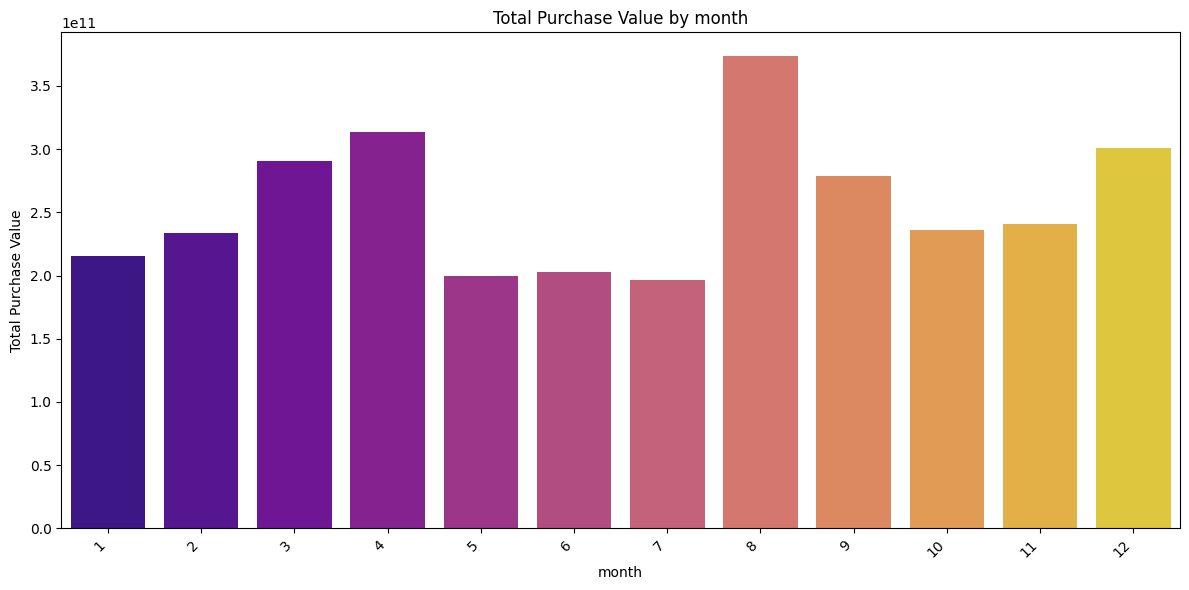

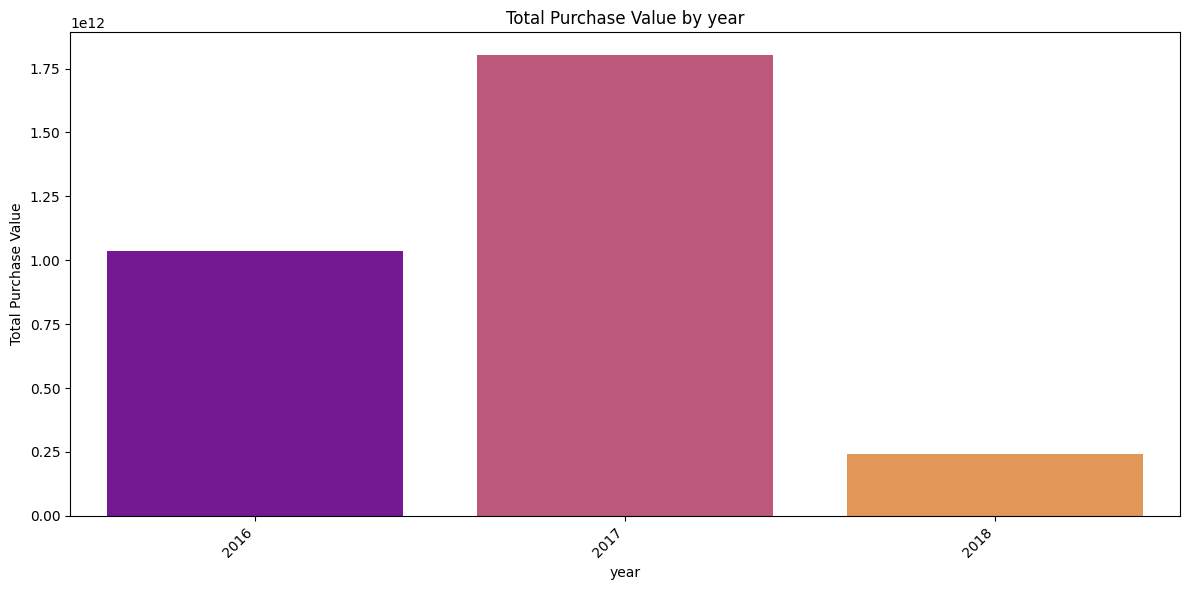

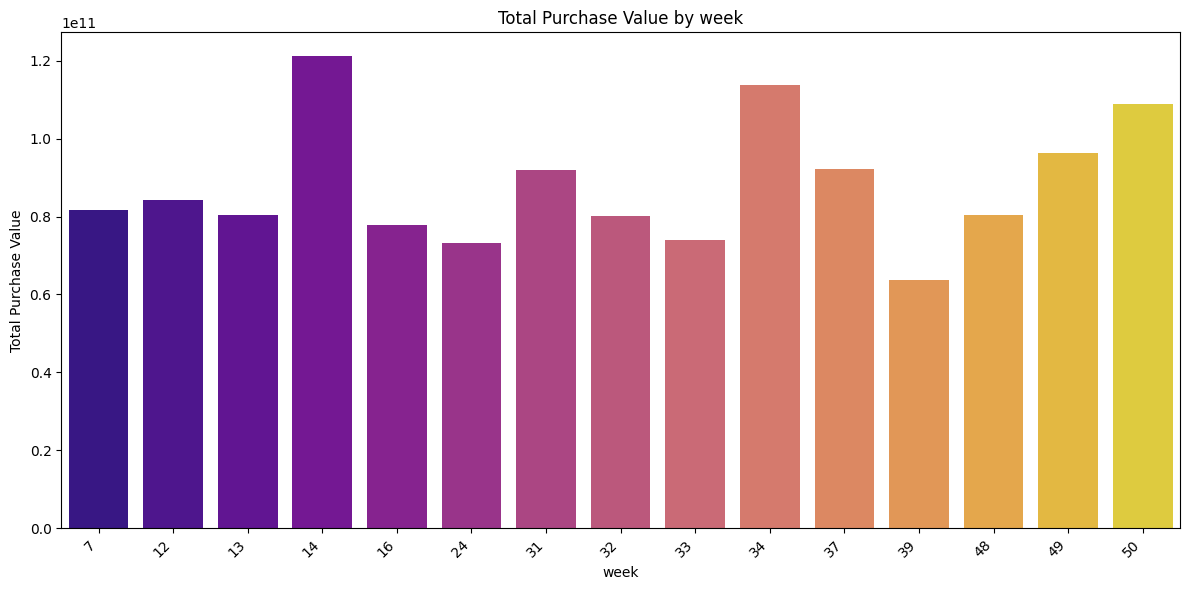

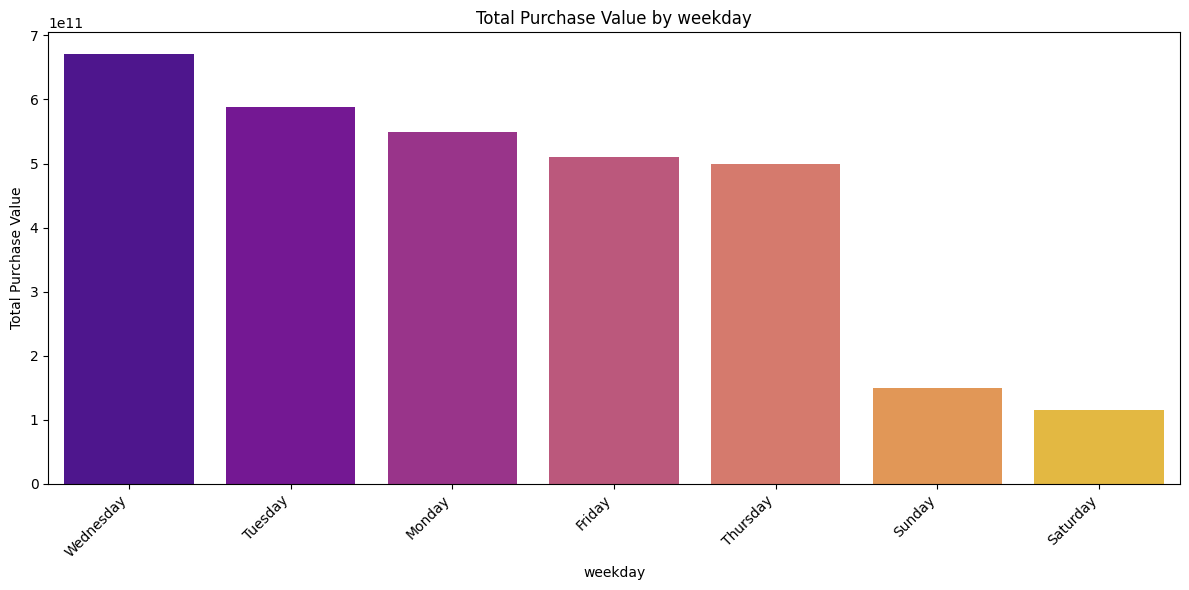

In [20]:
df["date"]=pd.to_datetime(df["date"],format='%Y%m%d')
df["month"]=df["date"].dt.month
df["day"]=df["date"].dt.day
df["year"]=df["date"].dt.year
df["week"] = df["date"].dt.isocalendar().week
df["weekday"] = df["date"].dt.day_name()  
date=["day","month","year","week","weekday"]
df[date] = df[date].fillna("others")
# Ensure purchaseValue is numeric
df["purchaseValue"] = pd.to_numeric(df["purchaseValue"], errors='coerce')

# Create bar plot for each feature
for col in date:
    plt.figure(figsize=(12, 6))
    grouped = df.groupby(col)["purchaseValue"].sum().sort_values(ascending=False).head(15)
    sns.barplot(x=grouped.index, y=grouped.values, palette="plasma")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Total Purchase Value by {col}")
    plt.xlabel(col)
    plt.ylabel("Total Purchase Value")
    plt.tight_layout()
    plt.show()

### Insights of dates on purchase value
**Week**
* weekends has less purchasing power.
* weekdays have more purchasing power.

**Year**
* 2017 has observed more purchase value.
* others has less purchase value.

**Month**
* August have more purchase Value.
* May, June, July has less purchasing value.

In [21]:
df.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

In [22]:
# df["trafficSource.isTrueDirect"].replace(np.nan,False,inplace=True)
# grouped = df.groupby("trafficSource.isTrueDirect")["purchaseValue"].sum()
# plt.figure(figsize=(6, 13))
# plt.bar(grouped.index, grouped.values,color="orange", edgecolor="black")
# plt.xlabel('trafficSource.isTrueDirect', fontsize=12)
# plt.ylabel('Purchase Value', fontsize=12)
# plt.title('Purchase Value per trafficSource.isTrueDirect', fontsize=14)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()
# plt.show()



### Uploading the datasets

In [23]:
#Train DATA Loading
data = pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv")
X =data.drop("purchaseValue",axis=1)
y=data[["purchaseValue"]]
pd.set_option('display.max_columns', None)
X
test=pd.read_csv("/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv")


In [24]:
data.shape

(116023, 52)

### Data Types

In [25]:
data.dtypes

trafficSource.isTrueDirect                       object
purchaseValue                                   float64
browser                                          object
device.screenResolution                          object
trafficSource.adContent                          object
trafficSource.keyword                            object
screenSize                                       object
geoCluster                                       object
trafficSource.adwordsClickInfo.slot              object
device.mobileDeviceBranding                      object
device.mobileInputSelector                       object
userId                                            int64
trafficSource.campaign                           object
device.mobileDeviceMarketingName                 object
geoNetwork.networkDomain                         object
gclIdPresent                                      int64
device.operatingSystemVersion                    object
sessionNumber                                   

### Insight on data types 
* The data types avaiable in this dataset are int, float, boolean, object
* Most of the values are objects.

### More information on datasets 

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116023 entries, 0 to 116022
Data columns (total 52 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   trafficSource.isTrueDirect                    42890 non-null   object 
 1   purchaseValue                                 116023 non-null  float64
 2   browser                                       116023 non-null  object 
 3   device.screenResolution                       116023 non-null  object 
 4   trafficSource.adContent                       2963 non-null    object 
 5   trafficSource.keyword                         44162 non-null   object 
 6   screenSize                                    116023 non-null  object 
 7   geoCluster                                    116023 non-null  object 
 8   trafficSource.adwordsClickInfo.slot           4281 non-null    object 
 9   device.mobileDeviceBranding                   11

### Insight on datatypes
* bool - (1)
* float64 - (5)
* int64 - (9)
* object - (37)
* trafficSource.adContent.trafficSource.adwordsClickInfo.isVideoAd,trafficSource.referralPath  : has more null values.
* userId and sessionId are unique Identifiers.

In [27]:
data["userId"].nunique()

100499

In [28]:
df["sessionId"].nunique()

107379

In [29]:
data

,trafficSource.isTrueDirect,purchaseValue,browser,device.screenResolution,trafficSource.adContent,trafficSource.keyword,screenSize,geoCluster,trafficSource.adwordsClickInfo.slot,device.mobileDeviceBranding,device.mobileInputSelector,userId,trafficSource.campaign,device.mobileDeviceMarketingName,geoNetwork.networkDomain,gclIdPresent,device.operatingSystemVersion,sessionNumber,device.flashVersion,geoNetwork.region,trafficSource,totals.visits,geoNetwork.networkLocation,sessionId,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,browserMajor,locationCountry,device.browserSize,trafficSource.adwordsClickInfo.adNetworkType,socialEngagementType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,locationZone,device.mobileDeviceModel,trafficSource.referralPath,totals.bounces,date,device.language,deviceType,userChannel,device.browserVersion,totalHits,device.screenColors,sessionStart,geoNetwork.continent,device.isMobile,new_visits
0,NaN,0.0,Edge,not available in demo dataset,NaN,NaN,medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,61421,(not set),not available in demo dataset,domain1,0,not available in demo dataset,1,not available in demo dataset,Washington,youtube.com,1,not available in demo dataset,1500100799,Windows,Northern America,referral,NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Redmond,NaN,Seattle-Tacoma WA,1.0,8,not available in demo dataset,/intl/hr/yt/about/,1.0,20170714,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1500100799,Americas,False,1.0
1,True,0.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,72287,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,California,(direct),1,not available in demo dataset,1495262065,Macintosh,Northern America,(none),NaN,not available in demo dataset,United States,not available in demo dataset,NaN,Not Socially Engaged,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,8,not available in demo dataset,NaN,1.0,20170519,not available in demo dataset,desktop,Direct,not available in demo dataset,1,not available in demo dataset,1495262065,Americas,False,1.0
2,True,0.0,Chrome,not available in demo dataset,NaN,(not provided),medium,Region_2,NaN,not available in demo dataset,not available in demo dataset,25180,(not set),not available in demo dataset,domain1,0,not available in demo dataset,2,not available in demo dataset,Lombardy,google,1,not available in demo dataset,1508510328,Windows,Southern Europe,organic,NaN,not available in demo dataset,Italy,not available in demo dataset,NaN,Not Socially Engaged,Milan,NaN,(not set),6.0,8,not available in demo dataset,NaN,NaN,20171020,not available in demo dataset,desktop,Organic Search,not available in demo dataset,6,not available in demo dataset,1508510328,Europe,False,NaN
3,NaN,0.0,Internet Explorer,not available in demo dataset,NaN,NaN,medium,Region_4,NaN,not available in demo dataset,not available in demo dataset,41295,(not set),not available in demo dataset,domain3,0,not available in demo dataset,1,not available in demo dataset,not available in demo dataset,youtube.com,1,not available in demo dataset,1483431838,Windows,Eastern Asia,referral,NaN,not available in demo dataset,Japan,not available in demo dataset,NaN,Not Socially Engaged,not available in demo dataset,NaN,not available in demo dataset,1.0,8,not available in demo dataset,/yt/about/ja/,1.0,20170103,not available in demo dataset,desktop,Social,not available in demo dataset,1,not available in demo dataset,1483431838,Asia,False,1.0
4,True,88950000.0,Chrome,not available in demo dataset,NaN,NaN,medium,Region_3,NaN,not available in demo dataset,not available in demo dataset,113697,(not set),not available in demo dataset,domain1,0,not available 

### Statiscal Analysis 

In [30]:
data.describe()

,purchaseValue,userId,gclIdPresent,sessionNumber,totals.visits,sessionId,trafficSource.adwordsClickInfo.page,pageViews,locationZone,totals.bounces,date,totalHits,sessionStart,new_visits
count,1.160230e+05,116023.000000,116023.000000,116023.000000,116023.0,1.160230e+05,4281.000000,116015.000000,116023.0,47148.0,1.160230e+05,116023.000000,1.160230e+05,80518.0
mean,2.656393e+07,61094.356231,0.037019,2.691311,1.0,1.493429e+09,1.019622,8.412352,8.0,1.0,2.016860e+07,10.607371,1.493429e+09,1.0
std,2.051825e+08,35240.756859,0.188808,10.451613,0.0,1.528798e+07,0.174517,14.344937,0.0,0.0,6.182322e+03,19.629576,1.528798e+07,0.0
min,0.000000e+00,0.000000,0.000000,1.000000,1.0,1.470035e+09,1.000000,1.000000,8.0,1.0,2.016080e+07,1.000000,1.470035e+09,1.0
25%,0.000000e+00,30603.500000,0.000000,1.000000,1.0,1.480066e+09,1.000000,1.000000,8.0,1.0,2.016112e+07,1.000000,1.480066e+09,1.0
50%,0.000000e+00,61014.000000,0.000000,1.000000,1.0,1.491646e+09,1.000000,2.000000,8.0,1.0,2.017041e+07,2.000000,1.491646e+09,1.0
75%,0.000000e+00,91616.500000,0.000000,2.000000,1.0,1.505079e+09,1.000000,10.000000,8.0,1.0,2.017091e+07,12.000000,1.505079e+09,1.0
max,2.312950e+10,122276.000000,1.000000,447.000000,1.0,1.525157e+09,5.000000,469.000000,8.0,1.0,2.018043e+07,500.000000,1.525157e+09,1.0


**Most Users Made No Purchase**
* purchaseValue has 0 as median, 25%, and 75%, while the mean is extremely inflated (~26M) due to rare outliers (max = 23.1B).
* Indicates a heavily right-skewed distribution — most users did not buy anything.
  
**Session Activity is Highly Uneven**
* sessionNumber has a median of 1 but a maximum of 447, suggesting that while most users had few sessions, some users visited excessively — potential power users or bots.

**locationZone Has No Variance**
* All values in locationZone are constant (8), so the feature provides no useful information and can be safely dropped.

**locationZone Has No Variance**
* All values in locationZone are constant (8), so the feature provides no useful information and can be safely dropped.

### Handling Unnessary Columns

In [31]:
data.isna().sum()

trafficSource.isTrueDirect                       73133
purchaseValue                                        0
browser                                              0
device.screenResolution                              0
trafficSource.adContent                         113060
trafficSource.keyword                            71861
screenSize                                           0
geoCluster                                           0
trafficSource.adwordsClickInfo.slot             111742
device.mobileDeviceBranding                          0
device.mobileInputSelector                           0
userId                                               0
trafficSource.campaign                               0
device.mobileDeviceMarketingName                     0
geoNetwork.networkDomain                             0
gclIdPresent                                         0
device.operatingSystemVersion                        0
sessionNumber                                        0
device.fla

### Insight 
* trafficSource.isTrueDirect,device.mobileDeviceModel,totals.bounces  ~ 50% null
* new_visits ~ 25% null.,
* trafficSource.adwordsClickInfo.isVideoAd ,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.adwordsClickInfo.page,device.screenResolution ~ 90% null

### Feature Elimination
Replacing useless symbols with null in traning and test datasets

In [32]:
data.replace('not available in demo dataset',np.nan,inplace=True)
# data.isna().sum()
data.replace("(not set)",np.nan,inplace=True)
# data.isna().sum()
data.replace("(not provided)",np.nan,inplace=True)
# data.isna().sum()
data.replace("Not Socially Engaged",np.nan,inplace=True)
# data.isna().sum()
data.replace("(none)",np.nan,inplace=True)
# data.isna().sum()

In [33]:
test.replace('not available in demo dataset',np.nan,inplace=True)
# data.isna().sum()
test.replace("(not set)",np.nan,inplace=True)
# data.isna().sum()
test.replace("(not provided)",np.nan,inplace=True)
# data.isna().sum()
test.replace("Not Socially Engaged",np.nan,inplace=True)
# data.isna().sum()
test.replace("(none)",np.nan,inplace=True)
# data.isna().sum()

### Idenity the columns containing only nan

In [34]:
nan_columns=["device.screenResolution","device.mobileDeviceBranding","device.mobileInputSelector","device.mobileDeviceMarketingName","device.operatingSystemVersion","device.flashVersion","browserMajor","device.browserSize","socialEngagementType","device.mobileDeviceModel","device.language","device.browserVersion","device.screenColors","geoNetwork.networkLocation"]
data[nan_columns].isna().sum()

device.screenResolution             116023
device.mobileDeviceBranding         116023
device.mobileInputSelector          116023
device.mobileDeviceMarketingName    116023
device.operatingSystemVersion       116023
device.flashVersion                 116023
browserMajor                        116023
device.browserSize                  116023
socialEngagementType                116023
device.mobileDeviceModel            116023
device.language                     116023
device.browserVersion               116023
device.screenColors                 116023
geoNetwork.networkLocation          116023
dtype: int64

### Insight
* Contains all useless value
* dropped.

In [35]:
high_cardinality=["sessionId","userId","sessionStart","locationZone","screenSize"]

### Insight
* date cannot be processed as it is.
* sessionId & sessionStart related almost similar representing unique identifier for session
* userId to uniquely identify the user.
* locationZone, screenSize has single value.
* dropped

### Identity the columns containing 95% of NaN

In [36]:
nan_95=["trafficSource.adContent","trafficSource.keyword","trafficSource.adwordsClickInfo.slot","trafficSource.campaign","trafficSource.adwordsClickInfo.isVideoAd","trafficSource.adwordsClickInfo.page","trafficSource.adwordsClickInfo.adNetworkType"]
data[nan_95].isna().sum()

trafficSource.adContent                         113060
trafficSource.keyword                           110927
trafficSource.adwordsClickInfo.slot             111742
trafficSource.campaign                          110280
trafficSource.adwordsClickInfo.isVideoAd        111742
trafficSource.adwordsClickInfo.page             111742
trafficSource.adwordsClickInfo.adNetworkType    111742
dtype: int64

### Insight 
* Contain 95% null
* retained as only few values had purchase value

### Columns containing single value

In [37]:
single_item=["trafficSource.isTrueDirect",'totals.visits']
for i in single_item:
    print(f"{i}:{data[i].value_counts()}")

trafficSource.isTrueDirect:trafficSource.isTrueDirect
True    42890
Name: count, dtype: int64
totals.visits:totals.visits
1    116023
Name: count, dtype: int64


### Droping the unnessary Columns

In [38]:
drop_columns=nan_columns+high_cardinality
len(drop_columns)
data=data.drop(drop_columns,axis=1)

In [39]:
test=test.drop(drop_columns,axis=1)
# test=test.drop(drop,axis=1)

In [40]:
data.shape

(116023, 33)

### Handling Missing Data
* **Columns containg null values:** With data not available in demo dataset . 
* **Columns with single item**: There is no varaince so drop.
* **Columns that have 95% null values**: More null values.

### Feature Creation

In [41]:
data["date"]=pd.to_datetime(data["date"],format='%Y%m%d')
data["month"]=data["date"].dt.month
#data["day"]=data["date"].dt.day
data["year"]=data["date"].dt.year
data

,trafficSource.isTrueDirect,purchaseValue,browser,trafficSource.adContent,trafficSource.keyword,geoCluster,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,geoNetwork.networkDomain,gclIdPresent,sessionNumber,geoNetwork.region,trafficSource,totals.visits,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,locationCountry,trafficSource.adwordsClickInfo.adNetworkType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,trafficSource.referralPath,totals.bounces,date,deviceType,userChannel,totalHits,geoNetwork.continent,device.isMobile,new_visits,month,year
0,NaN,0.0,Edge,NaN,NaN,Region_2,NaN,NaN,domain1,0,1,Washington,youtube.com,1,Windows,Northern America,referral,NaN,United States,NaN,Redmond,NaN,Seattle-Tacoma WA,1.0,/intl/hr/yt/about/,1.0,2017-07-14,desktop,Social,1,Americas,False,1.0,7,2017
1,True,0.0,Chrome,NaN,NaN,Region_3,NaN,NaN,domain3,0,1,California,(direct),1,Macintosh,Northern America,NaN,NaN,United States,NaN,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,NaN,1.0,2017-05-19,desktop,Direct,1,Americas,False,1.0,5,2017
2,True,0.0,Chrome,NaN,NaN,Region_2,NaN,NaN,domain1,0,2,Lombardy,google,1,Windows,Southern Europe,organic,NaN,Italy,NaN,Milan,NaN,NaN,6.0,NaN,NaN,2017-10-20,desktop,Organic Search,6,Europe,False,NaN,10,2017
3,NaN,0.0,Internet Explorer,NaN,NaN,Region_4,NaN,NaN,domain3,0,1,NaN,youtube.com,1,Windows,Eastern Asia,referral,NaN,Japan,NaN,NaN,NaN,NaN,1.0,/yt/about/ja/,1.0,2017-01-03,desktop,Social,1,Asia,False,1.0,1,2017
4,True,88950000.0,Chrome,NaN,NaN,Region_3,NaN,NaN,domain1,0,1,NaN,(direct),1,Windows,Northern America,NaN,NaN,United States,NaN,NaN,NaN,NaN,54.0,NaN,NaN,2016-10-06,desktop,Direct,66,Americas,False,1.0,10,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116018,NaN,35180000.0,Chrome,NaN,NaN,Region_3,NaN,NaN,domain1,0,1,New York,(direct),1,Macintosh,Northern America,NaN,NaN,United States,NaN,New York,NaN,New York NY,26.0,/,NaN,2017-07-17,desktop,Referral,28,Americas,False,1.0,7,2017
116019,True,0.0,Chrome,NaN,NaN,Region_5,NaN,NaN,domain2,0,1,California,(direct),1,Macintosh,Northern America,NaN,NaN,United States,NaN,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,NaN,1.0,2016-11-08,desktop,Direct,1,Americas,False,1.0,11,2016
116020,True,0.0,Chrome,NaN,NaN,Region_1,NaN,NaN,domain2,0,2,Delhi,seroundtable.com,1,Windows,Southern Asia,referral,NaN,India,NaN,New Delhi,NaN,NaN,1.0,/google-analytics-launches-public-demo-account...,1.0,2016-08-05,desktop,Referral,1,Asia,False,NaN,8,2016
116021,NaN,0.0,Chrome,NaN,NaN,Region_5,NaN,NaN,domain1,0,1,Tennessee,google,1,Windows,Northern America,organic,NaN,United States,NaN,Nashville,NaN,Nashville TN,2.0,NaN,NaN,2017-10-02,desktop,Organic Search,2,Americas,False,1.0,10,2017


In [42]:
test["date"]=pd.to_datetime(test["date"],format='%Y%m%d')
test["month"]=test["date"].dt.month
#test["day"]=test["date"].dt.day
test["year"]=test["date"].dt.year
test
data.drop("date",axis=1,inplace=True)
test.drop("date",axis=1,inplace=True)

### Insight
Since month and year impacted add those features.

### Handling null values

In [43]:
data.isna().sum()

trafficSource.isTrueDirect                       73133
purchaseValue                                        0
browser                                              1
trafficSource.adContent                         113060
trafficSource.keyword                           110927
geoCluster                                           0
trafficSource.adwordsClickInfo.slot             111742
trafficSource.campaign                          110280
geoNetwork.networkDomain                             0
gclIdPresent                                         0
sessionNumber                                        0
geoNetwork.region                                62944
trafficSource                                        4
totals.visits                                        0
os                                                 565
geoNetwork.subContinent                            136
trafficSource.medium                             36847
trafficSource.adwordsClickInfo.isVideoAd        111742
locationCo

In [44]:
data.shape

(116023, 34)

### Replacing nulls with most frequent values for categorical variables 

### Inspecting the numerical distribution

### Handling null values in numeric

In [45]:
from sklearn.impute import SimpleImputer

# const_impute=SimpleImputer(strategy="constant",fill_value=0).set_output(transform="pandas")
# num_impute=SimpleImputer(strategy="most_frequent").set_output(transform="pandas")


In [46]:
data[["trafficSource.adwordsClickInfo.isVideoAd","trafficSource.adwordsClickInfo.page"]]

,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.page
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
116018,NaN,NaN
116019,NaN,NaN
116020,NaN,NaN
116021,NaN,NaN


In [47]:
from sklearn.compose import ColumnTransformer

constant=["trafficSource.referralPath","geoNetwork.city","geoNetwork.subContinent","trafficSource.medium","locationCountry","geoNetwork.metro","geoNetwork.continent","geoNetwork.region","os","trafficSource.adContent","trafficSource.keyword","trafficSource.adwordsClickInfo.slot","trafficSource.campaign","trafficSource.adwordsClickInfo.adNetworkType"]
fill_0=["totals.bounces","new_visits"]
most_frequent=['pageViews',"browser" ,"geoCluster","trafficSource.adwordsClickInfo.page"]
fill_false=["trafficSource.isTrueDirect"]
fill_true=["trafficSource.adwordsClickInfo.isVideoAd"]
mode_impute=SimpleImputer(strategy="most_frequent")
zero_impute=SimpleImputer(strategy="constant",fill_value=0)
const_impute=SimpleImputer(strategy="constant",fill_value="constant")
false_impute=SimpleImputer(strategy="constant",fill_value=False)
true_impute=SimpleImputer(strategy="constant",fill_value=True)
impute_ct=ColumnTransformer(transformers=[("mi",mode_impute,most_frequent),
                            ("ci",const_impute,constant),
                            ("f0",zero_impute,fill_0),
                            ("true",true_impute,fill_true),
                             ("false",false_impute,fill_false)],remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

impute_ct.fit_transform(data).isna().sum()

pageViews                                       0
browser                                         0
geoCluster                                      0
trafficSource.adwordsClickInfo.page             0
trafficSource.referralPath                      0
geoNetwork.city                                 0
geoNetwork.subContinent                         0
trafficSource.medium                            0
locationCountry                                 0
geoNetwork.metro                                0
geoNetwork.continent                            0
geoNetwork.region                               0
os                                              0
trafficSource.adContent                         0
trafficSource.keyword                           0
trafficSource.adwordsClickInfo.slot             0
trafficSource.campaign                          0
trafficSource.adwordsClickInfo.adNetworkType    0
totals.bounces                                  0
new_visits                                      0


### Summary for handling null values
**Most frequent**: These data points where highly skewed .

**constant** :`Since the data points have high null values , so the null was replaced with the constant and create new category. 

**0,1,False**: Since these values contains and rest where null.

### Identifying Duplicates

In [48]:
data[data.duplicated()]

,trafficSource.isTrueDirect,purchaseValue,browser,trafficSource.adContent,trafficSource.keyword,geoCluster,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,geoNetwork.networkDomain,gclIdPresent,sessionNumber,geoNetwork.region,trafficSource,totals.visits,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,locationCountry,trafficSource.adwordsClickInfo.adNetworkType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,trafficSource.referralPath,totals.bounces,deviceType,userChannel,totalHits,geoNetwork.continent,device.isMobile,new_visits,month,year
1455,NaN,0.0,Chrome,NaN,NaN,Region_5,NaN,NaN,domain3,0,1,NaN,youtube.com,1,Windows,Western Asia,referral,NaN,Turkey,NaN,NaN,NaN,NaN,1.0,/yt/about/tr/,1.0,desktop,Social,1,Asia,False,1.0,10,2016
1902,NaN,0.0,Safari,NaN,NaN,Region_3,NaN,NaN,domain1,0,1,NaN,youtube.com,1,Macintosh,Southern Asia,referral,NaN,India,NaN,NaN,NaN,NaN,2.0,/yt/about/,NaN,desktop,Social,2,Asia,False,1.0,11,2016
2021,NaN,0.0,Safari,NaN,NaN,Region_5,NaN,NaN,domain2,0,1,NaN,google,1,iOS,Northern America,organic,NaN,United States,NaN,NaN,NaN,NaN,1.0,NaN,1.0,mobile,Organic Search,1,Americas,True,1.0,7,2017
2443,True,0.0,Opera,NaN,NaN,Region_2,NaN,NaN,domain2,0,1,Ohio,(direct),1,Windows,Northern America,NaN,NaN,United States,NaN,Columbus,NaN,Columbus OH,1.0,NaN,1.0,desktop,Direct,1,Americas,False,1.0,3,2017
2450,NaN,0.0,Chrome,NaN,NaN,Region_4,NaN,NaN,domain2,0,1,Istanbul,youtube.com,1,Windows,Western Asia,referral,NaN,Turkey,NaN,Istanbul,NaN,NaN,1.0,/yt/about/tr/,1.0,desktop,Social,1,Asia,False,1.0,9,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115930,True,0.0,Chrome,NaN,NaN,Region_2,NaN,NaN,domain1,0,1,NaN,(direct),1,Windows,Eastern Europe,NaN,NaN,Poland,NaN,NaN,NaN,NaN,1.0,NaN,1.0,desktop,Direct,1,Europe,False,1.0,3,2017
115944,NaN,0.0,Chrome,NaN,NaN,Region_2,NaN,NaN,domain3,0,1,Ho Chi Minh,youtube.com,1,Windows,Southeast Asia,referral,NaN,Vietnam,NaN,Ho Chi Minh City,NaN,NaN,2.0,/yt/about/,NaN,desktop,Social,2,Asia,False,1.0,10,2016
116006,NaN,0.0,Chrome,NaN,NaN,Region_1,NaN,NaN,domain3,0,1,NaN,google,1,Windows,Northern Europe,organic,NaN,United Kingdom,NaN,NaN,NaN,NaN,1.0,NaN,1.0,desktop,Organic Search,1,Europe,False,1.0,11,2017
116015,NaN,0.0,Chrome,NaN,NaN,Region_2,NaN,NaN,domain2,0,1,NaN,google,1,Windows,Northern America,organic,NaN,United States,NaN,NaN,NaN,NaN,3.0,NaN,NaN,desktop,Organic Search,3,Americas,False,1.0,11,2017


### Handling Duplicates
* Since there are 5304 rows repeated again.
* These where remove.

### Removing Dupplicates

In [49]:
data.drop_duplicates(inplace=True)
data.shape

(110719, 34)

In [50]:
categorical_columns = data.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
cat_unique_counts = {col: data[col].nunique() for col in categorical_columns}
cat_unique_counts

{'trafficSource.isTrueDirect': 1,
 'browser': 33,
 'trafficSource.adContent': 53,
 'trafficSource.keyword': 565,
 'geoCluster': 5,
 'trafficSource.adwordsClickInfo.slot': 3,
 'trafficSource.campaign': 27,
 'geoNetwork.networkDomain': 3,
 'geoNetwork.region': 386,
 'trafficSource': 160,
 'os': 17,
 'geoNetwork.subContinent': 22,
 'trafficSource.medium': 5,
 'trafficSource.adwordsClickInfo.isVideoAd': 1,
 'locationCountry': 192,
 'trafficSource.adwordsClickInfo.adNetworkType': 2,
 'geoNetwork.city': 693,
 'geoNetwork.metro': 102,
 'trafficSource.referralPath': 941,
 'deviceType': 3,
 'userChannel': 8,
 'geoNetwork.continent': 5,
 'device.isMobile': 2}

In [51]:
ohe_5=['browser','trafficSource.adContent','trafficSource.keyword','trafficSource.campaign','geoNetwork.region','trafficSource','os','geoNetwork.subContinent','locationCountry','geoNetwork.city','geoNetwork.metro','trafficSource.referralPath',"month"]
ohe=['geoCluster','trafficSource.adwordsClickInfo.slot','device.mobileDeviceBranding','geoNetwork.networkDomain','trafficSource.medium','deviceType', 'userChannel','geoNetwork.continent','device.isMobile',"year"]
label_encoding=['trafficSource.isTrueDirect','trafficSource.adwordsClickInfo.isVideoAd','trafficSource.adwordsClickInfo.adNetworkType']

In [52]:
# nominal=['browser', 'geoCluster','geoNetwork.networkDomain','geoNetwork.region', 'trafficSource','locationCountry', 'geoNetwork.metro', 'deviceType', 'userChannel', 'geoNetwork.continent', 'device.isMobile',"os","year","month","day"]
# data[nominal].dtypes
# len(nominal)
# for i,n in enumerate(nominal):
#     print(f"{n}:{data[n].nunique()}")

### Encoding
**One Hot Encoder**: Columns with low cardinality .
**Target Encoding**: Columns with high cardinality.

In [53]:
# target_encoding=["sessionId,""userId"]
ohe_5=['browser','trafficSource.adContent','trafficSource.keyword','trafficSource.campaign','geoNetwork.region','trafficSource','os','geoNetwork.subContinent','locationCountry','geoNetwork.city','geoNetwork.metro','trafficSource.referralPath',"month"]
ohe=['geoCluster','trafficSource.adwordsClickInfo.slot','device.mobileDeviceBranding','geoNetwork.networkDomain','trafficSource.medium','deviceType', 'userChannel','geoNetwork.continent','device.isMobile',"year","trafficSource.adwordsClickInfo.adNetworkType"]
label_encoding=['trafficSource.isTrueDirect','trafficSource.adwordsClickInfo.isVideoAd']

In [54]:
data[label_encoding].nunique()

trafficSource.isTrueDirect                  1
trafficSource.adwordsClickInfo.isVideoAd    1
dtype: int64

In [55]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
#target_encoding=["sessionId,""userId"]
ohe_5_list=['browser','trafficSource.adContent','trafficSource.keyword','trafficSource.campaign','geoNetwork.region','trafficSource','os','geoNetwork.subContinent','locationCountry','geoNetwork.city','geoNetwork.metro','trafficSource.referralPath',"month"]
ohe_list=['geoCluster','trafficSource.adwordsClickInfo.slot','geoNetwork.networkDomain','trafficSource.medium','deviceType', 'userChannel','geoNetwork.continent','device.isMobile',"year"]
label_encoding=['trafficSource.isTrueDirect','trafficSource.adwordsClickInfo.isVideoAd','trafficSource.adwordsClickInfo.adNetworkType']

ohe=("ohe",OneHotEncoder(sparse=False,drop="first",handle_unknown="ignore"),ohe_list)
ohe_5=("ohe-5",OneHotEncoder(sparse=False,drop="first",max_categories=6,handle_unknown="ignore"),ohe_5_list)
#te=("te",TargetEncoder(),target_encoding)
oe=("oe",OrdinalEncoder(),label_encoding)
encoding=ColumnTransformer(transformers=[
    ohe,ohe_5,oe
],verbose_feature_names_out=False,remainder="passthrough").set_output(transform="pandas")
encoding.fit_transform(data)

,geoCluster_Region_2,geoCluster_Region_3,geoCluster_Region_4,geoCluster_Region_5,trafficSource.adwordsClickInfo.slot_RHS,trafficSource.adwordsClickInfo.slot_Top,trafficSource.adwordsClickInfo.slot_nan,geoNetwork.networkDomain_domain2,geoNetwork.networkDomain_domain3,trafficSource.medium_cpc,trafficSource.medium_cpm,trafficSource.medium_organic,trafficSource.medium_referral,trafficSource.medium_nan,deviceType_mobile,deviceType_tablet,userChannel_Affiliates,userChannel_Direct,userChannel_Display,userChannel_Organic Search,userChannel_Paid Search,userChannel_Referral,userChannel_Social,geoNetwork.continent_Americas,geoNetwork.continent_Asia,geoNetwork.continent_Europe,geoNetwork.continent_Oceania,geoNetwork.continent_nan,device.isMobile_True,year_2017,year_2018,browser_Chrome,browser_Firefox,browser_Internet Explorer,browser_Safari,browser_infrequent_sklearn,trafficSource.adContent_Google Merchandise Collection,trafficSource.adContent_Google Merchandise Store,trafficSource.adContent_Placement Accessores 300 x 250,trafficSource.adContent_nan,trafficSource.adContent_infrequent_sklearn,trafficSource.keyword_(User vertical targeting),trafficSource.keyword_(automatic matching),trafficSource.keyword_6qEhsCssdK0z36ri,trafficSource.keyword_nan,trafficSource.keyword_infrequent_sklearn,trafficSource.campaign_AW - Accessories,trafficSource.campaign_AW - Dynamic Search Ads Whole Site,trafficSource.campaign_Data Share Promo,trafficSource.campaign_nan,trafficSource.campaign_infrequent_sklearn,geoNetwork.region_Illinois,geoNetwork.region_New York,geoNetwork.region_Texas,geoNetwork.region_nan,geoNetwork.region_infrequent_sklearn,trafficSource_analytics.google.com,trafficSource_google,trafficSource_mall.googleplex.com,trafficSource_youtube.com,trafficSource_infrequent_sklearn,os_Linux,os_Macintosh,os_Windows,os_iOS,os_infrequent_sklearn,geoNetwork.subContinent_Northern Europe,geoNetwork.subContinent_Southeast Asia,geoNetwork.subContinent_Southern Asia,geoNetwork.subContinent_Western Europe,geoNetwork.subContinent_infrequent_sklearn,locationCountry_India,locationCountry_Japan,locationCountry_United Kingdom,locationCountry_United States,locationCountry_infrequent_sklearn,geoNetwork.city_New York,geoNetwork.city_San Francisco,geoNetwork.city_Sunnyvale,geoNetwork.city_nan,geoNetwork.city_infrequent_sklearn,geoNetwork.metro_Los Angeles CA,geoNetwork.metro_New York NY,geoNetwork.metro_San Francisco-Oakland-San Jose CA,geoNetwork.metro_nan,geoNetwork.metro_infrequent_sklearn,trafficSource.referralPath_/analytics/web/,trafficSource.referralPath_/yt/about/,trafficSource.referralPath_/yt/about/es-419/,trafficSource.referralPath_nan,trafficSource.referralPath_infrequent_sklearn,month_8,month_10,month_11,month_12,month_infrequent_sklearn,trafficSource.isTrueDirect,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.adNetworkType,purchaseValue,gclIdPresent,sessionNumber,totals.visits,trafficSource.adwordsClickInfo.page,pageViews,totals.bounces,totalHits,new_visits
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0,1,1,NaN,1.0,1.0,1,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0,1,1,NaN,1.0,1.0,1,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,

In [56]:
numeric=['purchaseValue','gclIdPresent','pageViews', 'totals.bounces','totalHits','new_visits',"sessionNumber"]
data[numeric].dtypes
len(numeric)

7

### Insight
* **One Hot Encoding**: The nominal data containing less cardinality where encoded using One Hot Encoder.
* **One Hot Encoder with 5** : The high cardinality data and only top 5 and less then that contributed only top 4 and other where grouped and encoded.
* **Label Encoding**: Since this project doesn't use distance based algorithms these were encoded using label. 

### Identifying Outliers

In [57]:
numeric=data.select_dtypes(include="number")
for i,feature in enumerate(numeric):
    q1=data[feature].quantile(0.25)
    q3=data[feature].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    outliers=data[(data[feature]<lb)|(data[feature]>ub)]
    print(f"{feature}: {len(outliers)}")
    

purchaseValue: 23785
gclIdPresent: 4159
sessionNumber: 14068
totals.visits: 0
trafficSource.adwordsClickInfo.page: 64
pageViews: 9987
totals.bounces: 0
totalHits: 11342
new_visits: 0
month: 0
year: 0


### Handling Outliers
purchaseValue: 23785
gclIdPresent: 4159
sessionNumber: 14068
trafficSource.adwordsClickInfo.page: 64
pageViews: 9987
totalHits: 11342
** Since the test data is hidden retainde all the outliers.

In [58]:
numerical_features=data.select_dtypes(include=[np.number]).columns
numerical_features

Index(['purchaseValue', 'gclIdPresent', 'sessionNumber', 'totals.visits',
       'trafficSource.adwordsClickInfo.page', 'pageViews', 'totals.bounces',
       'totalHits', 'new_visits', 'month', 'year'],
      dtype='object')

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.preprocessing import StandardScaler, RobustScaler
ss_list=[]
rs_list=["sessionNumber","pageViews"]
rs=RobustScaler().set_output(transform="pandas")
rs.fit_transform(data[rs_list])

,sessionNumber,pageViews
0,0.0,-0.1
1,0.0,-0.1
2,1.0,0.4
3,0.0,-0.1
4,0.0,5.2
...,...,...
116017,0.0,-0.1
116018,0.0,2.4
116020,1.0,-0.1
116021,0.0,0.0


purchaseValue: 23789
gclIdPresent: 4255
sessionNumber: 14071
totals.visits: 0
pageViews: 12329
totals.bounces: 0
date: 0
totalHits: 13061
new_visits: 0

In [61]:
robust_tranformer=ColumnTransformer([("robust_sclaer",RobustScaler(),["sessionNumber","pageViews"])
                                   ],verbose_feature_names_out=False,remainder="passthrough")


In [62]:
from sklearn.pipeline import Pipeline
step=[("impute",impute_ct),
      ("encoding",encoding),
      ("scaling",robust_tranformer)
     ]
pipe=Pipeline(steps=step).set_output(transform="pandas")
pipe

Pipeline(steps=[('impute',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('mi',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['pageViews', 'browser',
                                                   'geoCluster',
                                                   'trafficSource.adwordsClickInfo.page']),
                                                 ('ci',
                                                  SimpleImputer(fill_value='constant',
                                                                strategy='constant'),
                                                  ['trafficSource.referralPath',
                                                   'geoNetwork.city',
                                                   'geoNetwork.subContinent',
                                                   'trafficS...
                                                   'month']),
                                                 ('oe', OrdinalEncoder(),
                                                  ['trafficSource.isTrueDirect',
                                                   'trafficSource.adwordsClickInfo.isVideoAd',
                                                   'trafficSource.adwordsClickInfo.adNetworkType'])],
                                   verbose_feature_names_out=False)),
                ('scaling',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('robust_sclaer',
                                                  RobustScaler(),
                                                  ['sessionNumber',
                                                   'pageViews'])],
                                   verbose_feature_names_out=False))])

In [63]:
# X_train["te"]
data.head()

,trafficSource.isTrueDirect,purchaseValue,browser,trafficSource.adContent,trafficSource.keyword,geoCluster,trafficSource.adwordsClickInfo.slot,trafficSource.campaign,geoNetwork.networkDomain,gclIdPresent,sessionNumber,geoNetwork.region,trafficSource,totals.visits,os,geoNetwork.subContinent,trafficSource.medium,trafficSource.adwordsClickInfo.isVideoAd,locationCountry,trafficSource.adwordsClickInfo.adNetworkType,geoNetwork.city,trafficSource.adwordsClickInfo.page,geoNetwork.metro,pageViews,trafficSource.referralPath,totals.bounces,deviceType,userChannel,totalHits,geoNetwork.continent,device.isMobile,new_visits,month,year
0,NaN,0.0,Edge,NaN,NaN,Region_2,NaN,NaN,domain1,0,1,Washington,youtube.com,1,Windows,Northern America,referral,NaN,United States,NaN,Redmond,NaN,Seattle-Tacoma WA,1.0,/intl/hr/yt/about/,1.0,desktop,Social,1,Americas,False,1.0,7,2017
1,True,0.0,Chrome,NaN,NaN,Region_3,NaN,NaN,domain3,0,1,California,(direct),1,Macintosh,Northern America,NaN,NaN,United States,NaN,Mountain View,NaN,San Francisco-Oakland-San Jose CA,1.0,NaN,1.0,desktop,Direct,1,Americas,False,1.0,5,2017
2,True,0.0,Chrome,NaN,NaN,Region_2,NaN,NaN,domain1,0,2,Lombardy,google,1,Windows,Southern Europe,organic,NaN,Italy,NaN,Milan,NaN,NaN,6.0,NaN,NaN,desktop,Organic Search,6,Europe,False,NaN,10,2017
3,NaN,0.0,Internet Explorer,NaN,NaN,Region_4,NaN,NaN,domain3,0,1,NaN,youtube.com,1,Windows,Eastern Asia,referral,NaN,Japan,NaN,NaN,NaN,NaN,1.0,/yt/about/ja/,1.0,desktop,Social,1,Asia,False,1.0,1,2017
4,True,88950000.0,Chrome,NaN,NaN,Region_3,NaN,NaN,domain1,0,1,NaN,(direct),1,Windows,Northern America,NaN,NaN,United States,NaN,NaN,NaN,NaN,54.0,NaN,NaN,desktop,Direct,66,Americas,False,1.0,10,2016


In [64]:

X_train=data.drop("purchaseValue",axis=1)
y_train=data["purchaseValue"]
pipe.fit(X_train,y_train)
pipe.transform(X_train)


,sessionNumber,pageViews,geoCluster_Region_2,geoCluster_Region_3,geoCluster_Region_4,geoCluster_Region_5,trafficSource.adwordsClickInfo.slot_RHS,trafficSource.adwordsClickInfo.slot_Top,trafficSource.adwordsClickInfo.slot_constant,geoNetwork.networkDomain_domain2,geoNetwork.networkDomain_domain3,trafficSource.medium_constant,trafficSource.medium_cpc,trafficSource.medium_cpm,trafficSource.medium_organic,trafficSource.medium_referral,deviceType_mobile,deviceType_tablet,userChannel_Affiliates,userChannel_Direct,userChannel_Display,userChannel_Organic Search,userChannel_Paid Search,userChannel_Referral,userChannel_Social,geoNetwork.continent_Americas,geoNetwork.continent_Asia,geoNetwork.continent_Europe,geoNetwork.continent_Oceania,geoNetwork.continent_constant,device.isMobile_True,year_2017,year_2018,browser_Chrome,browser_Firefox,browser_Internet Explorer,browser_Safari,browser_infrequent_sklearn,trafficSource.adContent_Google Merchandise Collection,trafficSource.adContent_Google Merchandise Store,trafficSource.adContent_Placement Accessores 300 x 250,trafficSource.adContent_constant,trafficSource.adContent_infrequent_sklearn,trafficSource.keyword_(User vertical targeting),trafficSource.keyword_(automatic matching),trafficSource.keyword_6qEhsCssdK0z36ri,trafficSource.keyword_constant,trafficSource.keyword_infrequent_sklearn,trafficSource.campaign_AW - Accessories,trafficSource.campaign_AW - Dynamic Search Ads Whole Site,trafficSource.campaign_Data Share Promo,trafficSource.campaign_constant,trafficSource.campaign_infrequent_sklearn,geoNetwork.region_Illinois,geoNetwork.region_New York,geoNetwork.region_Texas,geoNetwork.region_constant,geoNetwork.region_infrequent_sklearn,trafficSource_analytics.google.com,trafficSource_google,trafficSource_mall.googleplex.com,trafficSource_youtube.com,trafficSource_infrequent_sklearn,os_Linux,os_Macintosh,os_Windows,os_iOS,os_infrequent_sklearn,geoNetwork.subContinent_Northern Europe,geoNetwork.subContinent_Southeast Asia,geoNetwork.subContinent_Southern Asia,geoNetwork.subContinent_Western Europe,geoNetwork.subContinent_infrequent_sklearn,locationCountry_India,locationCountry_Japan,locationCountry_United Kingdom,locationCountry_United States,locationCountry_infrequent_sklearn,geoNetwork.city_New York,geoNetwork.city_San Francisco,geoNetwork.city_Sunnyvale,geoNetwork.city_constant,geoNetwork.city_infrequent_sklearn,geoNetwork.metro_Los Angeles CA,geoNetwork.metro_New York NY,geoNetwork.metro_San Francisco-Oakland-San Jose CA,geoNetwork.metro_constant,geoNetwork.metro_infrequent_sklearn,trafficSource.referralPath_/analytics/web/,trafficSource.referralPath_/yt/about/,trafficSource.referralPath_/yt/about/es-419/,trafficSource.referralPath_constant,trafficSource.referralPath_infrequent_sklearn,month_8,month_10,month_11,month_12,month_infrequent_sklearn,trafficSource.isTrueDirect,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.adwordsClickInfo.page,totals.bounces,new_visits,gclIdPresent,totals.visits,totalHits
0,0.0,-0.1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,0,1,1
1,0.0,-0.1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,0,1,1
2,1.0,0.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.

In [65]:
X_train=pipe.transform(X_train)
X_train.shape

(110719, 107)

In [66]:
X_test=pipe.transform(test)
X_test.shape

(29006, 107)

In [67]:
X_train

,sessionNumber,pageViews,geoCluster_Region_2,geoCluster_Region_3,geoCluster_Region_4,geoCluster_Region_5,trafficSource.adwordsClickInfo.slot_RHS,trafficSource.adwordsClickInfo.slot_Top,trafficSource.adwordsClickInfo.slot_constant,geoNetwork.networkDomain_domain2,geoNetwork.networkDomain_domain3,trafficSource.medium_constant,trafficSource.medium_cpc,trafficSource.medium_cpm,trafficSource.medium_organic,trafficSource.medium_referral,deviceType_mobile,deviceType_tablet,userChannel_Affiliates,userChannel_Direct,userChannel_Display,userChannel_Organic Search,userChannel_Paid Search,userChannel_Referral,userChannel_Social,geoNetwork.continent_Americas,geoNetwork.continent_Asia,geoNetwork.continent_Europe,geoNetwork.continent_Oceania,geoNetwork.continent_constant,device.isMobile_True,year_2017,year_2018,browser_Chrome,browser_Firefox,browser_Internet Explorer,browser_Safari,browser_infrequent_sklearn,trafficSource.adContent_Google Merchandise Collection,trafficSource.adContent_Google Merchandise Store,trafficSource.adContent_Placement Accessores 300 x 250,trafficSource.adContent_constant,trafficSource.adContent_infrequent_sklearn,trafficSource.keyword_(User vertical targeting),trafficSource.keyword_(automatic matching),trafficSource.keyword_6qEhsCssdK0z36ri,trafficSource.keyword_constant,trafficSource.keyword_infrequent_sklearn,trafficSource.campaign_AW - Accessories,trafficSource.campaign_AW - Dynamic Search Ads Whole Site,trafficSource.campaign_Data Share Promo,trafficSource.campaign_constant,trafficSource.campaign_infrequent_sklearn,geoNetwork.region_Illinois,geoNetwork.region_New York,geoNetwork.region_Texas,geoNetwork.region_constant,geoNetwork.region_infrequent_sklearn,trafficSource_analytics.google.com,trafficSource_google,trafficSource_mall.googleplex.com,trafficSource_youtube.com,trafficSource_infrequent_sklearn,os_Linux,os_Macintosh,os_Windows,os_iOS,os_infrequent_sklearn,geoNetwork.subContinent_Northern Europe,geoNetwork.subContinent_Southeast Asia,geoNetwork.subContinent_Southern Asia,geoNetwork.subContinent_Western Europe,geoNetwork.subContinent_infrequent_sklearn,locationCountry_India,locationCountry_Japan,locationCountry_United Kingdom,locationCountry_United States,locationCountry_infrequent_sklearn,geoNetwork.city_New York,geoNetwork.city_San Francisco,geoNetwork.city_Sunnyvale,geoNetwork.city_constant,geoNetwork.city_infrequent_sklearn,geoNetwork.metro_Los Angeles CA,geoNetwork.metro_New York NY,geoNetwork.metro_San Francisco-Oakland-San Jose CA,geoNetwork.metro_constant,geoNetwork.metro_infrequent_sklearn,trafficSource.referralPath_/analytics/web/,trafficSource.referralPath_/yt/about/,trafficSource.referralPath_/yt/about/es-419/,trafficSource.referralPath_constant,trafficSource.referralPath_infrequent_sklearn,month_8,month_10,month_11,month_12,month_infrequent_sklearn,trafficSource.isTrueDirect,trafficSource.adwordsClickInfo.isVideoAd,trafficSource.adwordsClickInfo.adNetworkType,trafficSource.adwordsClickInfo.page,totals.bounces,new_visits,gclIdPresent,totals.visits,totalHits
0,0.0,-0.1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,1.0,1.0,1.0,0,1,1
1,0.0,-0.1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,0,1,1
2,1.0,0.4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.

In [68]:
X_train.dtypes

sessionNumber          float64
pageViews              float64
geoCluster_Region_2    float64
geoCluster_Region_3    float64
geoCluster_Region_4    float64
                        ...   
totals.bounces         float64
new_visits             float64
gclIdPresent             int64
totals.visits            int64
totalHits                int64
Length: 107, dtype: object

### Model building

### 1. Random Forest

In [69]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import r2_score, mean_squared_error
# random_forest=RandomForestRegressor(random_state=42)
# random_forest.fit(X_train,y_train)
# y_pred=random_forest.predict(X_test)
# y_train_pred=random_forest.predict(X_train)
# print(f"r2 score on train:{r2_score(y_train,y_train_pred)}")
# print(f"mean square error on train : {mean_squared_error(y_train,y_train_pred)}")
# # print(f"mean square error on validation : {mean_squared_error(y_train,y_train_pred)")

* r2_score on train : 0.93122
* r2_score on test : 0.4002
* mean squared error on train : 3025134944793420.0
* mean squared error on val :
* fitting : overfitting

In [70]:
# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred}) 
# submission.to_csv('submission.csv',index=False)

In [71]:
# important=pd.Series(random_forest.feature_importances_,index=X_train.columns).sort_values(ascending=False)
# print(important.head(25))

In [72]:
X_train["trafficSource.adwordsClickInfo.page"] = X_train["trafficSource.adwordsClickInfo.page"].astype(float)
X_test["trafficSource.adwordsClickInfo.page"] = X_test["trafficSource.adwordsClickInfo.page"].astype(float)

### 2.XGBoost

In [73]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
xgb=XGBRegressor(random_state=42,enable_categorical=True)
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)
y_train_pred=xgb.predict(X_train)
print(f"r2 score on train:{r2_score(y_train,y_train_pred)}")
print(f"mean square error on train : {mean_squared_error(y_train,y_train_pred)}")


r2 score on train:0.8325705322150183
mean square error on train : 7364696819529336.0


In [74]:
# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred}) 
# submission.to_csv('submission.csv',index=False)

* r2_score on train : 0.832570
* r2_score on test : 0.47
* mean squared error on train : 7364696819529336.0
* mean squared error on val :
* fitting : overfit

### 3.Gradient Boosting Regressor 

In [75]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.metrics import r2_score, mean_squared_error
# gb= GradientBoostingRegressor(random_state=42)
# gb.fit(X_train,y_train)
# y_pred=gb.predict(X_test)
# y_train_pred=gb.predict(X_train)
# print(f"r2 score on train:{r2_score(y_train,y_train_pred)}")
# print(f"mean square error on train : {mean_squared_error(y_train,y_train_pred)}")

In [76]:
# submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": y_pred}) 
# submission.to_csv('submission.csv',index=False)

* r2_score in train : 0.62589
* r2_score on test : 0.24
* mean squared error on train : 1.6455788744163022e+16
* mean squared error on val : overfit

### Comparsion Tabel


| Model                  | R² (Train) | R² (Test) | MSE (Train) | Fit Time (s) |
|------------------------|------------|-----------|-------------|--------------|
| Gradient Boosting       | 0.62      | 0.247      | 1.6e+16     | over fit         |
| Random Forest     | 0.93122      | 0.4002    | 3025134944793420.0      | over fit      |
| XGBoost                | 0.832      | 0.47      | 7364696819529336.0      | over fit       |


### Feature Engineering

In [77]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
xg = XGBRegressor(random_state=42)
rfe = RFE(estimator=xgb, n_features_to_select=25)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)
selected_features = X_train.columns[rfe.support_]
print("Selected features:", selected_features.tolist())

Selected features: ['sessionNumber', 'pageViews', 'geoCluster_Region_3', 'geoNetwork.networkDomain_domain3', 'trafficSource.medium_cpm', 'userChannel_Direct', 'geoNetwork.continent_Oceania', 'year_2017', 'browser_Chrome', 'browser_Internet Explorer', 'geoNetwork.region_infrequent_sklearn', 'os_Linux', 'os_Macintosh', 'os_Windows', 'locationCountry_Japan', 'locationCountry_infrequent_sklearn', 'geoNetwork.city_San Francisco', 'geoNetwork.city_Sunnyvale', 'geoNetwork.city_constant', 'geoNetwork.metro_Los Angeles CA', 'geoNetwork.metro_infrequent_sklearn', 'month_8', 'month_12', 'month_infrequent_sklearn', 'totalHits']


**"Selected features:"** "sessionNumber","totalHits","pageViews","geoCluster_Region_3","month_8","month_infrequent_sklearn", "month_12", "userChannel_Direct","os_Windows", "geoNetwork.networkDomain_domain3", "geoCluster_Region_4", "geoCluster_Region_2","year_2017", "geoNetwork.networkDomain_domain2", "geoNetwork.metro_infrequent_sklearn", "geoNetwork.region_infrequent_sklearn","os_infrequent_sklearn","geoCluster_Region_5","geoNetwork.city_constant",
"os_Macintosh","trafficSource.isTrueDirect","month_11","trafficSource.medium_constant","geoNetwork.city_San Francisco",
"geoNetwork.metro_San Francisco-Oakland-San Jose CA"

### HyperParameter tuning

In [78]:
 # Define the parameter grid
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['auto', 'sqrt']
}
xg=XGBRegressor(random_sate=42)
grid_search = GridSearchCV( estimator=xgb,
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train_rfe, y_train)
print("Best Parameters:", grid_search.best_params_)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [06:44:05] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [06:44:05] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [06:44:05] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [06:44:06] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/loc

Best Parameters: {'max_depth': None, 'max_features': 'auto', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2,'n_estimators': 200}


In [79]:
g_predict = grid_search.predict(X_test_rfe)

In [80]:
submission = pd.DataFrame({"id": range(0,X_test.shape[0]), "purchaseValue": g_predict}) 
submission.to_csv('submission.csv',index=False)

r2_score on train :0.95
r2_score : 0.52